<a href="https://colab.research.google.com/github/AnupamaGautam05/M-Tech-EMB/blob/automotive-embedded-systems/notebook/block-diagrams.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Colab is making it easier than ever to integrate powerful Generative AI capabilities into your projects. We are launching public preview for a simple and intuitive Python library (google.colab.ai) to access state-of-the-art language models directly within Colab environments. All users have free access to most popular LLMs, while paid users have access to a wider selection of models. This means users can spend less time on configuration and set up and more time bringing their ideas to life. With just a few lines of code, you can now perform a variety of tasks:
- Generate text
- Translate languages
- Write creative content
- Categorize text

Happy Coding!


[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/googlecolab/colabtools/blob/main/notebooks/Getting_started_with_google_colab_ai.ipynb)

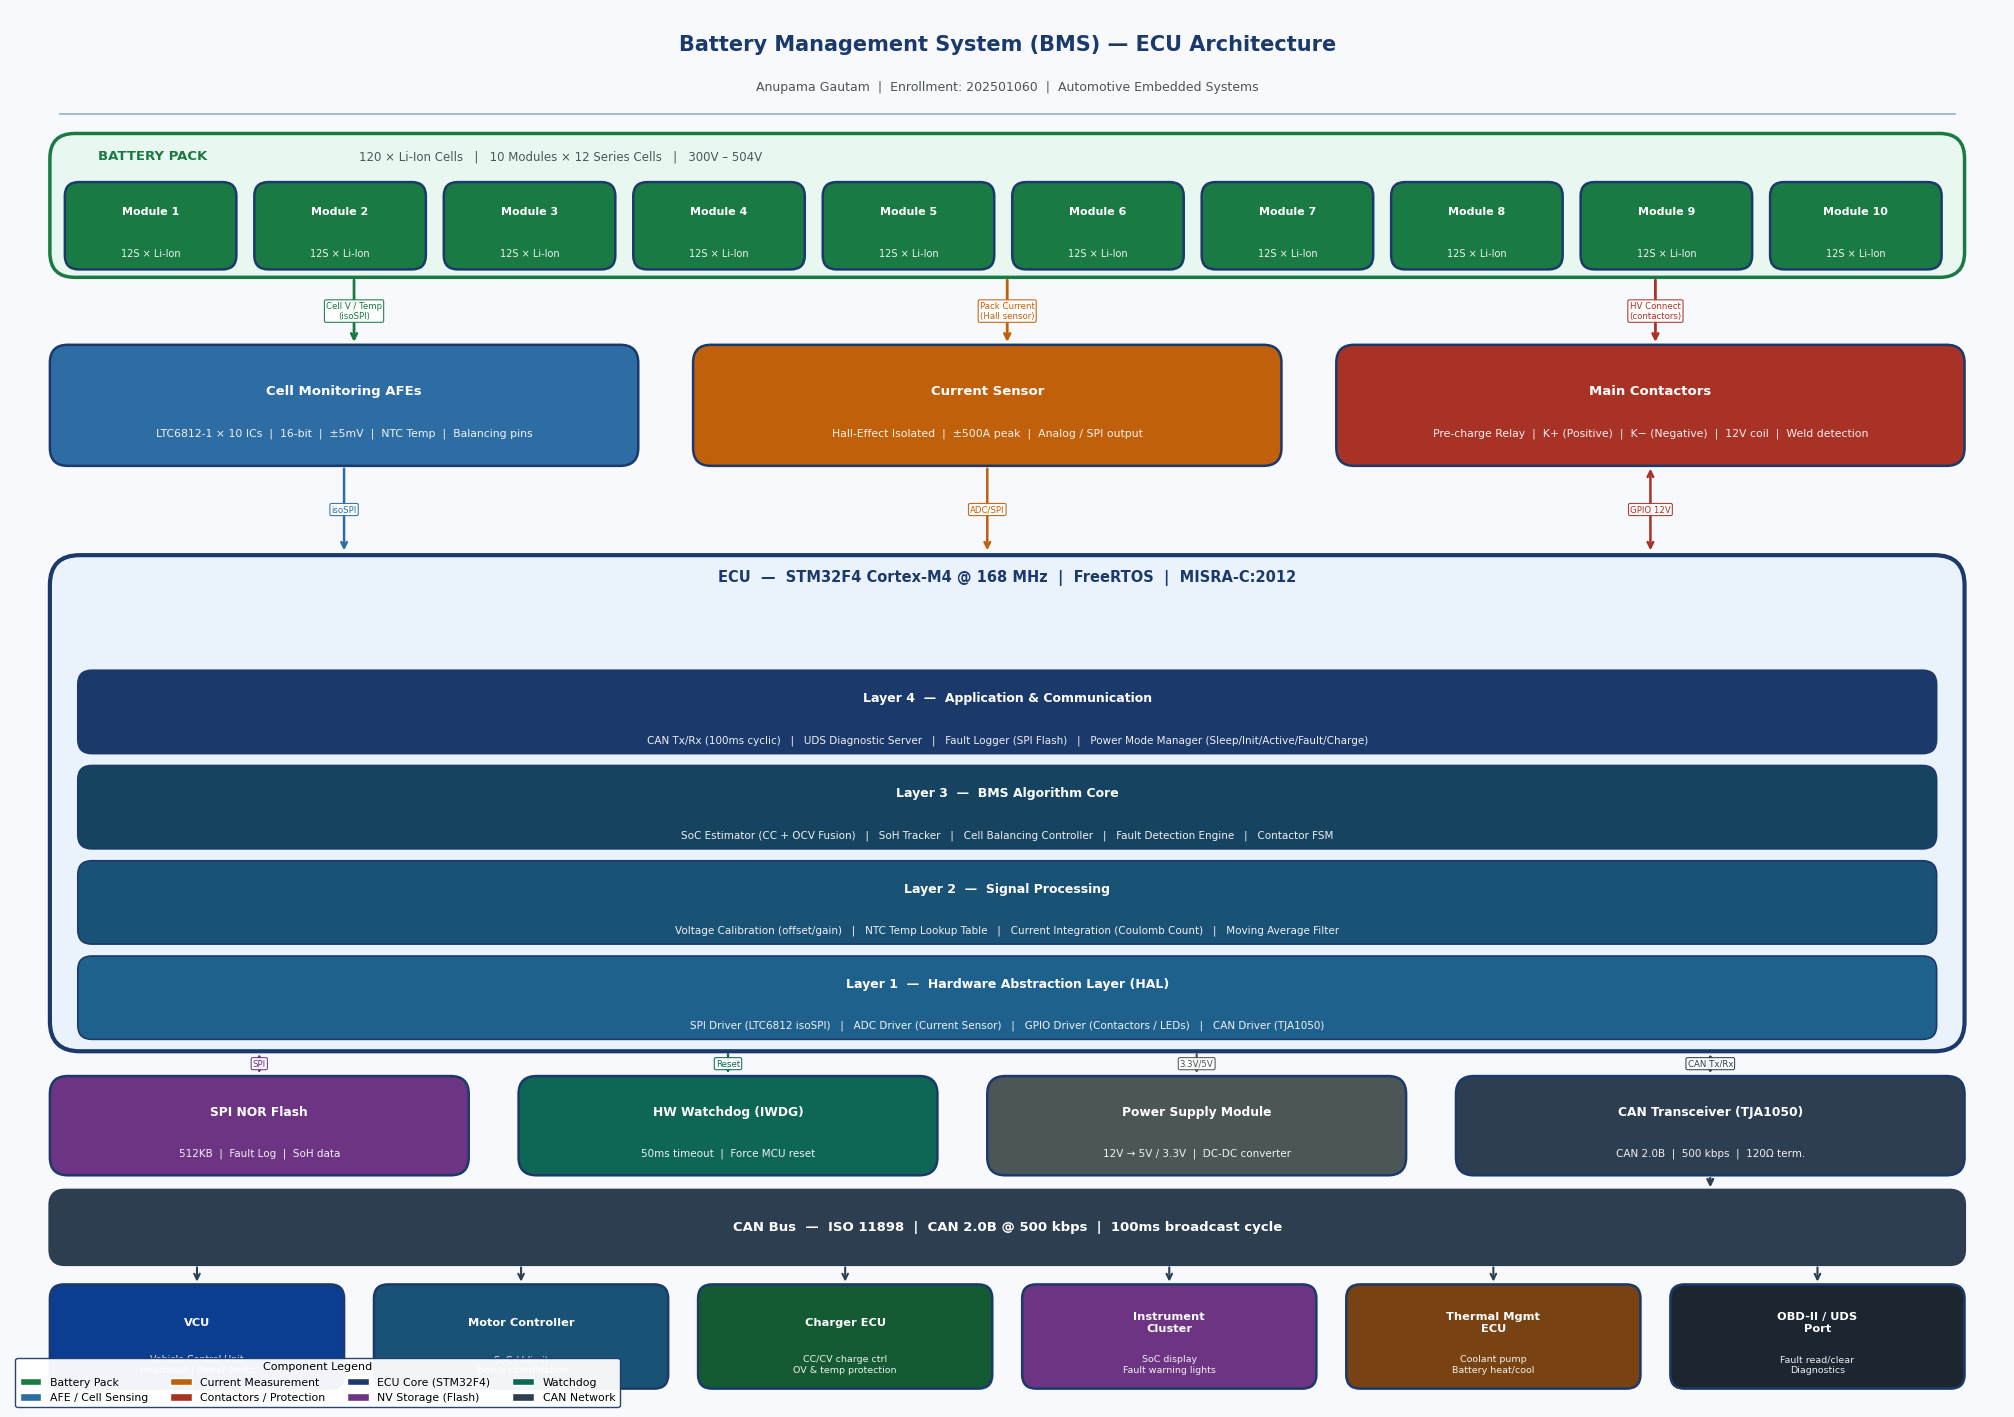

Saved: BMS_Block_Diagram_v2.png


In [1]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch
import matplotlib.patheffects as pe

fig, ax = plt.subplots(figsize=(20, 14))
ax.set_xlim(0, 20)
ax.set_ylim(0, 14)
ax.axis('off')
fig.patch.set_facecolor('#F7F9FC')
ax.set_facecolor('#F7F9FC')

# ── Colors ────────────────────────────────────────────────────────────────────
NAVY    = '#1B3A6B'
BLUE    = '#2E6DA4'
LBLUE   = '#EAF2FB'
GREEN   = '#1A7A43'
LGREEN  = '#E8F8F0'
ORANGE  = '#C0600A'
LORANGE = '#FEF0E6'
RED     = '#A93226'
LRED    = '#FDEDEC'
PURPLE  = '#6C3483'
LPURP   = '#F4ECF7'
GRAY    = '#4D5656'
LGRAY   = '#F0F3F4'
TEAL    = '#0E6655'
LTEAL   = '#E8F6F3'
WHITE   = '#FFFFFF'
DGRAY   = '#2C3E50'

# ── Helper: rounded box ───────────────────────────────────────────────────────
def box(x, y, w, h, title, sub='', fc=BLUE, tc=WHITE, tfc=None,
        border=NAVY, fs=9, sfs=7.5, lw=1.8, radius=0.18):
    patch = FancyBboxPatch((x, y), w, h,
                            boxstyle=f"round,pad=0.0,rounding_size={radius}",
                            linewidth=lw, edgecolor=border, facecolor=fc, zorder=3)
    ax.add_patch(patch)
    # title bar
    if tfc:
        tbar = FancyBboxPatch((x, y+h-0.42), w, 0.42,
                               boxstyle=f"round,pad=0.0,rounding_size={radius}",
                               linewidth=0, facecolor=tfc, zorder=4)
        ax.add_patch(tbar)
    cy = y + h/2 + (0.14 if sub else 0)
    ax.text(x+w/2, cy, title, ha='center', va='center',
            fontsize=fs, fontweight='bold', color=tc, zorder=5,
            multialignment='center')
    if sub:
        ax.text(x+w/2, y+h/2 - 0.28, sub, ha='center', va='center',
                fontsize=sfs, color=tc, zorder=5, multialignment='center',
                alpha=0.92)

# ── Helper: arrow ─────────────────────────────────────────────────────────────
def arr(x1,y1,x2,y2, label='', col=NAVY, lw=1.6, bi=False, rad=0.0,
        lstyle='solid'):
    style = '<->' if bi else '->'
    ax.annotate('', xy=(x2,y2), xytext=(x1,y1),
                arrowprops=dict(arrowstyle=style, color=col, lw=lw,
                                linestyle=lstyle,
                                connectionstyle=f'arc3,rad={rad}'),
                zorder=6)
    if label:
        mx, my = (x1+x2)/2, (y1+y2)/2
        ax.text(mx, my, label, fontsize=6.2, color=col, ha='center', va='center',
                bbox=dict(boxstyle='round,pad=0.18', fc='white', ec=col,
                          alpha=0.92, lw=0.8), zorder=7)

# ── Helper: horizontal bus line ───────────────────────────────────────────────
def hline(x1, x2, y, col=NAVY, lw=2.2):
    ax.plot([x1,x2],[y,y], color=col, lw=lw, zorder=5, solid_capstyle='round')

def vline(x, y1, y2, col=NAVY, lw=1.6):
    ax.plot([x,x],[y1,y2], color=col, lw=lw, zorder=5, solid_capstyle='round')

# ════════════════════════════════════════════════════════════════════════════════
# TITLE
# ════════════════════════════════════════════════════════════════════════════════
ax.text(10, 13.65, 'Battery Management System (BMS) — ECU Architecture',
        ha='center', va='center', fontsize=15, fontweight='bold', color=NAVY,
        zorder=10)
ax.text(10, 13.22, 'Anupama Gautam  |  Enrollment: 202501060  |  Automotive Embedded Systems',
        ha='center', va='center', fontsize=9, color=GRAY, zorder=10)
ax.plot([0.5, 19.5], [12.95, 12.95], color=BLUE, lw=1.2, alpha=0.5)

# ════════════════════════════════════════════════════════════════════════════════
# ROW 1 — BATTERY PACK  (y: 11.4 – 12.7)
# ════════════════════════════════════════════════════════════════════════════════
# Outer container
bp = FancyBboxPatch((0.4, 11.3), 19.2, 1.45,
                     boxstyle="round,pad=0.0,rounding_size=0.25",
                     linewidth=2.5, edgecolor=GREEN, facecolor=LGREEN, zorder=2)
ax.add_patch(bp)
ax.text(0.88, 12.52, 'BATTERY PACK', fontsize=9.5, fontweight='bold',
        color=GREEN, va='center', zorder=5)
ax.text(3.5, 12.52, '120 × Li-Ion Cells   |   10 Modules × 12 Series Cells   |   300V – 504V',
        fontsize=8.5, color=GRAY, va='center', zorder=5)

# 10 module cells — evenly spaced
for i in range(10):
    mx = 0.55 + i * 1.90
    box(mx, 11.38, 1.72, 0.88,
        f'Module {i+1}', '12S × Li-Ion',
        fc=GREEN, tc=WHITE, fs=8, sfs=7, radius=0.14)

# ════════════════════════════════════════════════════════════════════════════════
# ARROWS: Battery → Hardware row
# ════════════════════════════════════════════════════════════════════════════════
# Three downward arrows from pack to hardware
arr(3.45, 11.3, 3.45, 10.62, 'Cell V / Temp\n(isoSPI)', GREEN, lw=2.0)
arr(10.0, 11.3, 10.0, 10.62, 'Pack Current\n(Hall sensor)', ORANGE, lw=2.0)
arr(16.5, 11.3, 16.5, 10.62, 'HV Connect\n(contactors)', RED, lw=2.0)

# ════════════════════════════════════════════════════════════════════════════════
# ROW 2 — HARDWARE SENSING  (y: 9.4 – 10.6)
# ════════════════════════════════════════════════════════════════════════════════
# AFE ICs
box(0.4, 9.4, 5.9, 1.22,
    'Cell Monitoring AFEs', 'LTC6812-1 × 10 ICs  |  16-bit  |  ±5mV  |  NTC Temp  |  Balancing pins',
    fc=BLUE, tc=WHITE, fs=9.5, sfs=7.8)

# Current Sensor
box(6.85, 9.4, 5.9, 1.22,
    'Current Sensor', 'Hall-Effect Isolated  |  ±500A peak  |  Analog / SPI output',
    fc='#C0600A', tc=WHITE, fs=9.5, sfs=7.8)

# Contactors
box(13.3, 9.4, 6.3, 1.22,
    'Main Contactors', 'Pre-charge Relay  |  K+ (Positive)  |  K− (Negative)  |  12V coil  |  Weld detection',
    fc=RED, tc=WHITE, fs=9.5, sfs=7.8)

# ════════════════════════════════════════════════════════════════════════════════
# ARROWS: Hardware → ECU (HAL layer)
# ════════════════════════════════════════════════════════════════════════════════
arr(3.35, 9.4, 3.35, 8.52,  'isoSPI',  BLUE,   lw=1.8)
arr(9.8,  9.4, 9.8,  8.52,  'ADC/SPI', ORANGE, lw=1.8)
arr(16.45,9.4, 16.45,8.52,  'GPIO 12V', RED,   lw=1.8, bi=True)

# ════════════════════════════════════════════════════════════════════════════════
# ROW 3 — ECU INTERNAL (4 layers)  y: 3.6 – 8.5
# ════════════════════════════════════════════════════════════════════════════════
ECU_X, ECU_Y, ECU_W, ECU_H = 0.4, 3.5, 19.2, 5.0

# ECU outer border
ecu_outer = FancyBboxPatch((ECU_X, ECU_Y), ECU_W, ECU_H,
                             boxstyle="round,pad=0.0,rounding_size=0.3",
                             linewidth=3.0, edgecolor=NAVY, facecolor='#EAF2FB',
                             zorder=2)
ax.add_patch(ecu_outer)

ax.text(ECU_X + ECU_W/2, ECU_Y + ECU_H - 0.22,
        'ECU  —  STM32F4 Cortex-M4 @ 168 MHz  |  FreeRTOS  |  MISRA-C:2012',
        ha='center', va='center', fontsize=10.5, fontweight='bold', color=NAVY, zorder=5)

# Layer dimensions
LX = ECU_X + 0.28
LW = ECU_W - 0.56
LH = 0.84
LGAP = 0.12

layer_data = [
    # (y,       title,                   subtitle,                                                fc)
    (ECU_Y+0.12, 'Layer 1  —  Hardware Abstraction Layer (HAL)',
                  'SPI Driver (LTC6812 isoSPI)   |   ADC Driver (Current Sensor)   |   GPIO Driver (Contactors / LEDs)   |   CAN Driver (TJA1050)',
                  '#1F618D'),
    (ECU_Y+0.12+LH+LGAP, 'Layer 2  —  Signal Processing',
                  'Voltage Calibration (offset/gain)   |   NTC Temp Lookup Table   |   Current Integration (Coulomb Count)   |   Moving Average Filter',
                  '#1A5276'),
    (ECU_Y+0.12+2*(LH+LGAP), 'Layer 3  —  BMS Algorithm Core',
                  'SoC Estimator (CC + OCV Fusion)   |   SoH Tracker   |   Cell Balancing Controller   |   Fault Detection Engine   |   Contactor FSM',
                  '#154360'),
    (ECU_Y+0.12+3*(LH+LGAP), 'Layer 4  —  Application & Communication',
                  'CAN Tx/Rx (100ms cyclic)   |   UDS Diagnostic Server   |   Fault Logger (SPI Flash)   |   Power Mode Manager (Sleep/Init/Active/Fault/Charge)',
                  NAVY),
]

for (ly, ltitle, lsub, lfc) in layer_data:
    box(LX, ly, LW, LH, ltitle, lsub,
        fc=lfc, tc=WHITE, fs=9.0, sfs=7.5, radius=0.14, lw=1.2)

# ════════════════════════════════════════════════════════════════════════════════
# SIDE PERIPHERALS (attached to ECU sides)
# ════════════════════════════════════════════════════════════════════════════════
# -- SPI Flash (right of ECU)
box(0.4, 2.25, 4.2, 1.0,
    'SPI NOR Flash', '512KB  |  Fault Log  |  SoH data',
    fc=PURPLE, tc=WHITE, fs=8.8, sfs=7.5)
arr(2.5, 3.5, 2.5, 3.25, 'SPI', PURPLE, lw=1.6, bi=True)

# -- Watchdog
box(5.1, 2.25, 4.2, 1.0,
    'HW Watchdog (IWDG)', '50ms timeout  |  Force MCU reset',
    fc=TEAL, tc=WHITE, fs=8.8, sfs=7.5)
arr(7.2, 3.5, 7.2, 3.25, 'Reset', TEAL, lw=1.6)

# -- Power Supply
box(9.8, 2.25, 4.2, 1.0,
    'Power Supply Module', '12V → 5V / 3.3V  |  DC-DC converter',
    fc=GRAY, tc=WHITE, fs=8.8, sfs=7.5)
arr(11.9, 3.5, 11.9, 3.25, '3.3V/5V', GRAY, lw=1.6)

# -- CAN Transceiver
box(14.5, 2.25, 5.1, 1.0,
    'CAN Transceiver (TJA1050)', 'CAN 2.0B  |  500 kbps  |  120Ω term.',
    fc=DGRAY, tc=WHITE, fs=8.8, sfs=7.5)
arr(17.05, 3.5, 17.05, 3.25, 'CAN Tx/Rx', DGRAY, lw=1.8, bi=True)

# ════════════════════════════════════════════════════════════════════════════════
# ROW 5 — CAN BUS BACKBONE  (y: 1.4 – 1.95)
# ════════════════════════════════════════════════════════════════════════════════
canbus = FancyBboxPatch((0.4, 1.35), 19.2, 0.75,
                          boxstyle="round,pad=0.0,rounding_size=0.15",
                          linewidth=2.2, edgecolor=DGRAY, facecolor=DGRAY, zorder=3)
ax.add_patch(canbus)
ax.text(10, 1.725, 'CAN Bus  —  ISO 11898  |  CAN 2.0B @ 500 kbps  |  100ms broadcast cycle',
        ha='center', va='center', fontsize=9.5, fontweight='bold', color=WHITE, zorder=5)

# Arrow from CAN Transceiver → CAN bus
arr(17.05, 2.25, 17.05, 2.1, '', DGRAY, lw=1.8)

# ════════════════════════════════════════════════════════════════════════════════
# ROW 6 — EXTERNAL ECUs  (y: 0.1 – 1.15)
# ════════════════════════════════════════════════════════════════════════════════
ext = [
    (0.40,  '#0B3D91', 'VCU',              'Vehicle Control Unit\nHeartbeat | Power limits'),
    (3.65,  '#1A5276', 'Motor Controller', 'SoC / I-limit\nTorque coordination'),
    (6.90,  '#145A32', 'Charger ECU',      'CC/CV charge ctrl\nOV & temp protection'),
    (10.15, '#6C3483', 'Instrument\nCluster','SoC display\nFault warning lights'),
    (13.40, '#784212', 'Thermal Mgmt\nECU','Coolant pump\nBattery heat/cool'),
    (16.65, '#1B2631', 'OBD-II / UDS\nPort','Fault read/clear\nDiagnostics'),
]

EW = 2.95
for (ex, efc, etitle, esub) in ext:
    box(ex, 0.1, EW, 1.05, etitle, esub,
        fc=efc, tc=WHITE, fs=8.2, sfs=6.8, radius=0.14)

# Vertical drops from CAN bus → each external ECU
for (ex, *_) in ext:
    cx = ex + EW/2
    arr(cx, 1.35, cx, 1.15, '', DGRAY, lw=1.5)

# ════════════════════════════════════════════════════════════════════════════════
# LEGEND
# ════════════════════════════════════════════════════════════════════════════════
legend_items = [
    mpatches.Patch(facecolor=GREEN,  edgecolor='white', label='Battery Pack'),
    mpatches.Patch(facecolor=BLUE,   edgecolor='white', label='AFE / Cell Sensing'),
    mpatches.Patch(facecolor=ORANGE, edgecolor='white', label='Current Measurement'),
    mpatches.Patch(facecolor=RED,    edgecolor='white', label='Contactors / Protection'),
    mpatches.Patch(facecolor=NAVY,   edgecolor='white', label='ECU Core (STM32F4)'),
    mpatches.Patch(facecolor=PURPLE, edgecolor='white', label='NV Storage (Flash)'),
    mpatches.Patch(facecolor=TEAL,   edgecolor='white', label='Watchdog'),
    mpatches.Patch(facecolor=DGRAY,  edgecolor='white', label='CAN Network'),
]
ax.legend(handles=legend_items, loc='lower left', fontsize=7.8,
          framealpha=0.95, edgecolor=NAVY, ncol=4,
          bbox_to_anchor=(0.0, -0.01),
          title='Component Legend', title_fontsize=8)

plt.tight_layout(pad=0.2)
plt.savefig('BMS_Block_Diagram_v2.png', dpi=220, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()
print("Saved: BMS_Block_Diagram_v2.png")


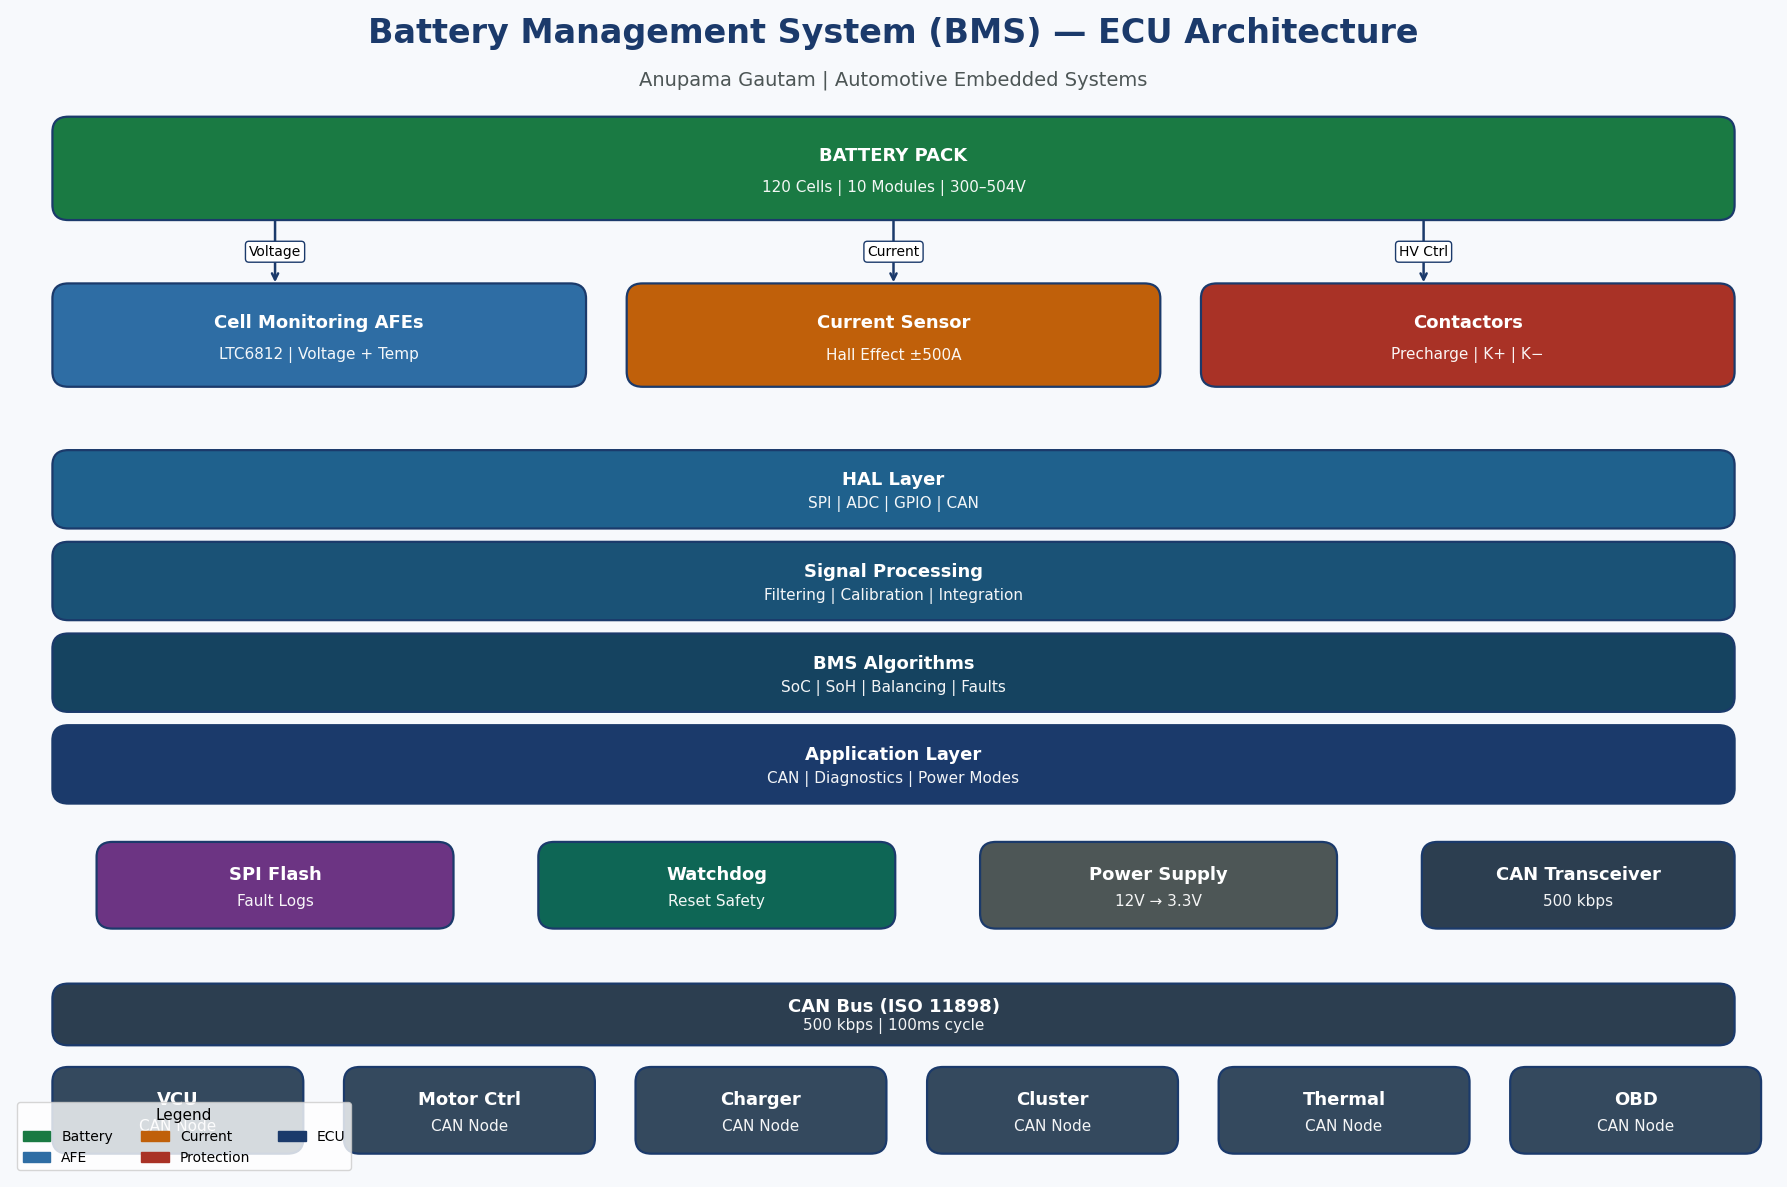

In [2]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch

# ─────────────────────────────────────────────────────────────
# GLOBAL FONT SYSTEM (Publication Quality)
# ─────────────────────────────────────────────────────────────
TITLE_FS   = 24
SUBTITLE_FS= 14
SECTION_FS = 13
BODY_FS    = 11
SMALL_FS   = 10
LABEL_FS   = 10

plt.rcParams.update({
    "font.size": BODY_FS,
    "font.family": "DejaVu Sans"
})

# ─────────────────────────────────────────────────────────────
# FIGURE
# ─────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(18, 12))
ax.set_xlim(0, 20)
ax.set_ylim(0, 14)
ax.axis('off')

fig.patch.set_facecolor('#F7F9FC')
ax.set_facecolor('#F7F9FC')

# ─────────────────────────────────────────────────────────────
# COLORS
# ─────────────────────────────────────────────────────────────
NAVY    = '#1B3A6B'
BLUE    = '#2E6DA4'
GREEN   = '#1A7A43'
LGREEN  = '#E8F8F0'
ORANGE  = '#C0600A'
RED     = '#A93226'
PURPLE  = '#6C3483'
GRAY    = '#4D5656'
DGRAY   = '#2C3E50'
WHITE   = '#FFFFFF'
TEAL    = '#0E6655'

# ─────────────────────────────────────────────────────────────
# BOX FUNCTION (Improved Typography)
# ─────────────────────────────────────────────────────────────
def box(x, y, w, h, title, sub='',
        fc=BLUE, tc=WHITE,
        fs=SECTION_FS, sfs=BODY_FS):

    patch = FancyBboxPatch((x, y), w, h,
                           boxstyle="round,pad=0.02,rounding_size=0.18",
                           linewidth=1.6, edgecolor=NAVY,
                           facecolor=fc)
    ax.add_patch(patch)

    ax.text(x + w/2, y + h*0.62,
            title, ha='center', va='center',
            fontsize=fs, fontweight='bold', color=tc)

    if sub:
        ax.text(x + w/2, y + h*0.30,
                sub, ha='center', va='center',
                fontsize=sfs, color=tc, alpha=0.95)

# ─────────────────────────────────────────────────────────────
# ARROW FUNCTION (Readable Labels)
# ─────────────────────────────────────────────────────────────
def arr(x1, y1, x2, y2, label='', col=NAVY, bi=False):

    style = '<->' if bi else '->'

    ax.annotate('', xy=(x2,y2), xytext=(x1,y1),
                arrowprops=dict(arrowstyle=style,
                                color=col, lw=1.8))

    if label:
        ax.text((x1+x2)/2, (y1+y2)/2,
                label, fontsize=LABEL_FS,
                ha='center', va='center',
                bbox=dict(boxstyle='round,pad=0.25',
                          fc='white', ec=col, lw=1))

# ─────────────────────────────────────────────────────────────
# TITLE
# ─────────────────────────────────────────────────────────────
ax.text(10, 13.6,
        'Battery Management System (BMS) — ECU Architecture',
        ha='center', fontsize=TITLE_FS,
        fontweight='bold', color=NAVY)

ax.text(10, 13.1,
        'Anupama Gautam | Automotive Embedded Systems',
        ha='center', fontsize=SUBTITLE_FS,
        color=GRAY)

# ─────────────────────────────────────────────────────────────
# BATTERY PACK
# ─────────────────────────────────────────────────────────────
box(0.5, 11.5, 19, 1.2,
    'BATTERY PACK',
    '120 Cells | 10 Modules | 300–504V',
    fc=GREEN)

# ─────────────────────────────────────────────────────────────
# HARDWARE
# ─────────────────────────────────────────────────────────────
box(0.5, 9.5, 6, 1.2,
    'Cell Monitoring AFEs',
    'LTC6812 | Voltage + Temp',
    fc=BLUE)

box(7, 9.5, 6, 1.2,
    'Current Sensor',
    'Hall Effect ±500A',
    fc=ORANGE)

box(13.5, 9.5, 6, 1.2,
    'Contactors',
    'Precharge | K+ | K−',
    fc=RED)

# ─────────────────────────────────────────────────────────────
# ECU LAYERS
# ─────────────────────────────────────────────────────────────
box(0.5, 7.8, 19, 0.9,
    'HAL Layer',
    'SPI | ADC | GPIO | CAN',
    fc='#1F618D')

box(0.5, 6.7, 19, 0.9,
    'Signal Processing',
    'Filtering | Calibration | Integration',
    fc='#1A5276')

box(0.5, 5.6, 19, 0.9,
    'BMS Algorithms',
    'SoC | SoH | Balancing | Faults',
    fc='#154360')

box(0.5, 4.5, 19, 0.9,
    'Application Layer',
    'CAN | Diagnostics | Power Modes',
    fc=NAVY)

# ─────────────────────────────────────────────────────────────
# SIDE COMPONENTS
# ─────────────────────────────────────────────────────────────
box(1, 3, 4, 1, 'SPI Flash', 'Fault Logs', fc=PURPLE)
box(6, 3, 4, 1, 'Watchdog', 'Reset Safety', fc=TEAL)
box(11, 3, 4, 1, 'Power Supply', '12V → 3.3V', fc=GRAY)
box(16, 3, 3.5, 1, 'CAN Transceiver', '500 kbps', fc=DGRAY)

# ─────────────────────────────────────────────────────────────
# CAN BUS
# ─────────────────────────────────────────────────────────────
box(0.5, 1.6, 19, 0.7,
    'CAN Bus (ISO 11898)',
    '500 kbps | 100ms cycle',
    fc=DGRAY)

# ─────────────────────────────────────────────────────────────
# EXTERNAL ECUs
# ─────────────────────────────────────────────────────────────
names = ['VCU', 'Motor Ctrl', 'Charger', 'Cluster', 'Thermal', 'OBD']
xpos = [0.5, 3.8, 7.1, 10.4, 13.7, 17]

for i, name in enumerate(names):
    box(xpos[i], 0.3, 2.8, 1,
        name, 'CAN Node', fc='#34495E')

# ─────────────────────────────────────────────────────────────
# CONNECTIONS
# ─────────────────────────────────────────────────────────────
arr(3, 11.5, 3, 10.7, 'Voltage')
arr(10, 11.5, 10, 10.7, 'Current')
arr(16, 11.5, 16, 10.7, 'HV Ctrl')

# ─────────────────────────────────────────────────────────────
# LEGEND
# ─────────────────────────────────────────────────────────────
legend_items = [
    mpatches.Patch(color=GREEN, label='Battery'),
    mpatches.Patch(color=BLUE, label='AFE'),
    mpatches.Patch(color=ORANGE, label='Current'),
    mpatches.Patch(color=RED, label='Protection'),
    mpatches.Patch(color=NAVY, label='ECU'),
]

ax.legend(handles=legend_items,
          loc='lower left',
          fontsize=SMALL_FS,
          title='Legend',
          title_fontsize=BODY_FS,
          ncol=3)

# ─────────────────────────────────────────────────────────────
# SAVE
# ─────────────────────────────────────────────────────────────
plt.tight_layout()
plt.savefig('BMS_Diagram_Refactored.png',
            dpi=300, bbox_inches='tight')
plt.show()

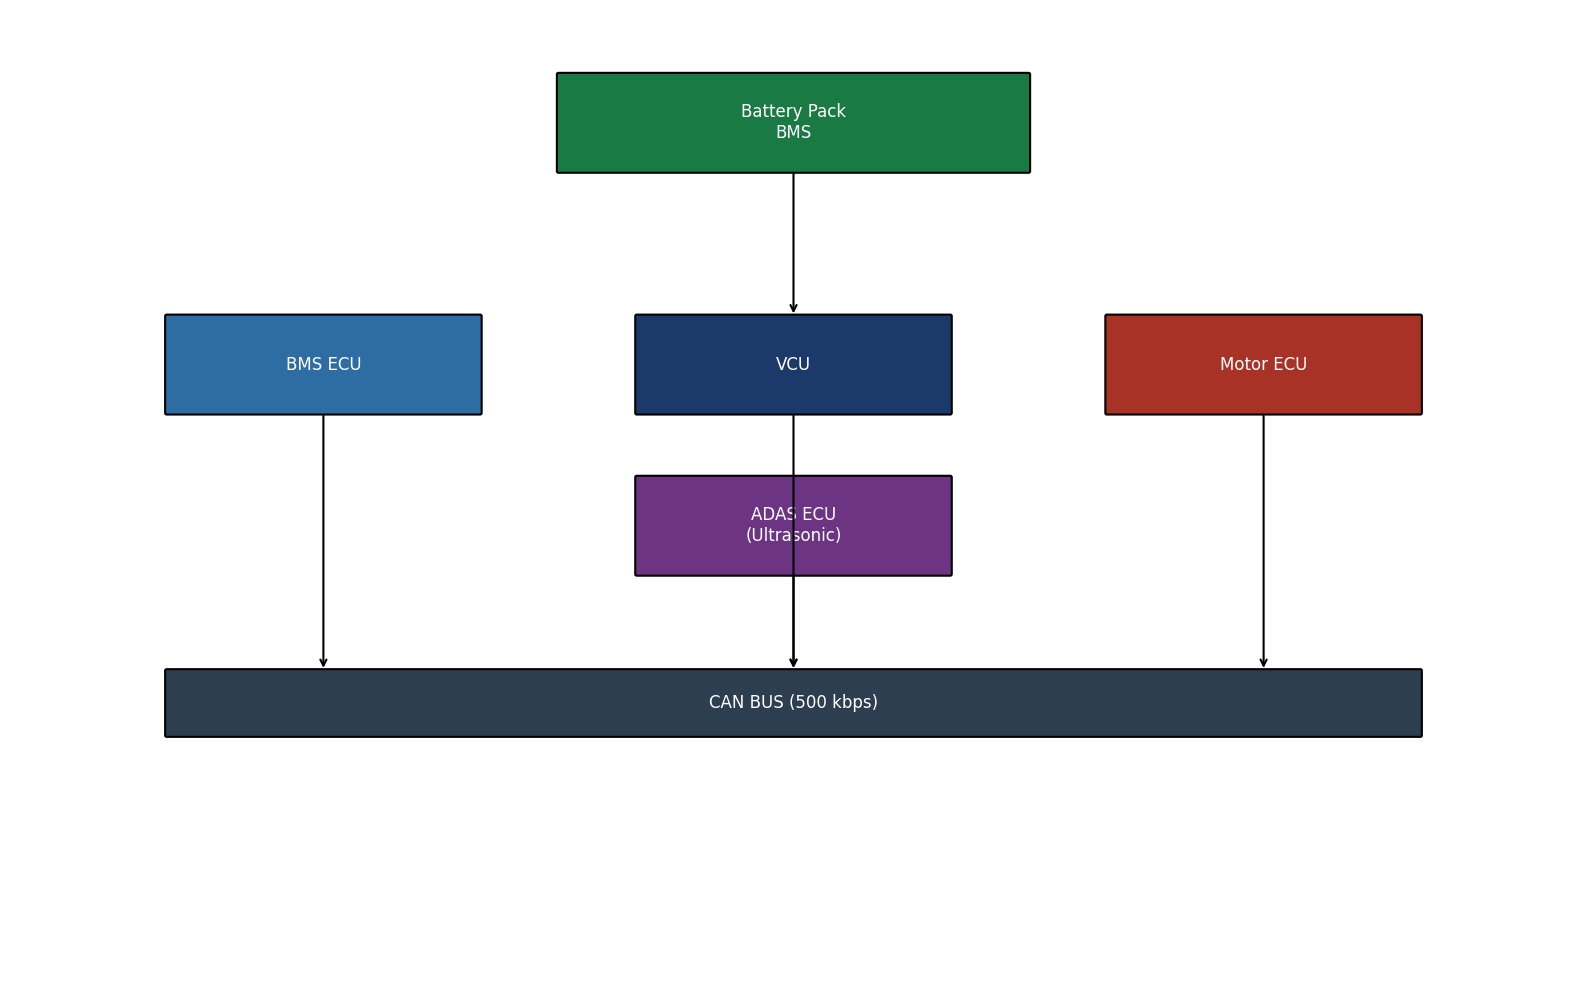

In [3]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch

# ─────────────────────────────────────────
# FONT SYSTEM
# ─────────────────────────────────────────
TITLE = 20
SECTION = 12
TEXT = 10

fig, ax = plt.subplots(figsize=(16, 10))
ax.set_xlim(0, 20)
ax.set_ylim(0, 12)
ax.axis('off')

# ─────────────────────────────────────────
# BOX FUNCTION
# ─────────────────────────────────────────
def box(x, y, w, h, text, color):
    rect = FancyBboxPatch((x, y), w, h,
                          boxstyle="round,pad=0.02",
                          fc=color, ec='black', lw=1.5)
    ax.add_patch(rect)
    ax.text(x+w/2, y+h/2, text,
            ha='center', va='center',
            fontsize=SECTION, color='white')

# ─────────────────────────────────────────
# ARROW FUNCTION
# ─────────────────────────────────────────
def arrow(x1, y1, x2, y2):
    ax.annotate('', xy=(x2,y2), xytext=(x1,y1),
                arrowprops=dict(arrowstyle='->', lw=1.5))

# ─────────────────────────────────────────
# TOP: BATTERY
# ─────────────────────────────────────────
box(7, 10, 6, 1.2, "Battery Pack\nBMS", "#1A7A43")

# ─────────────────────────────────────────
# MIDDLE: ECUs
# ─────────────────────────────────────────
box(2, 7, 4, 1.2, "BMS ECU", "#2E6DA4")
box(8, 7, 4, 1.2, "VCU", "#1B3A6B")
box(14, 7, 4, 1.2, "Motor ECU", "#A93226")

# ─────────────────────────────────────────
# ADAS
# ─────────────────────────────────────────
box(8, 5, 4, 1.2, "ADAS ECU\n(Ultrasonic)", "#6C3483")

# ─────────────────────────────────────────
# CAN BUS
# ─────────────────────────────────────────
box(2, 3, 16, 0.8, "CAN BUS (500 kbps)", "#2C3E50")

# ─────────────────────────────────────────
# CONNECTIONS
# ─────────────────────────────────────────
arrow(10,10,10,8.2)
arrow(4,7,4,3.8)
arrow(10,7,10,3.8)
arrow(16,7,16,3.8)
arrow(10,5,10,3.8)

# ─────────────────────────────────────────
# SAVE
# ─────────────────────────────────────────
plt.tight_layout()
plt.savefig("EV_System_Diagram.png", dpi=300)
plt.show()

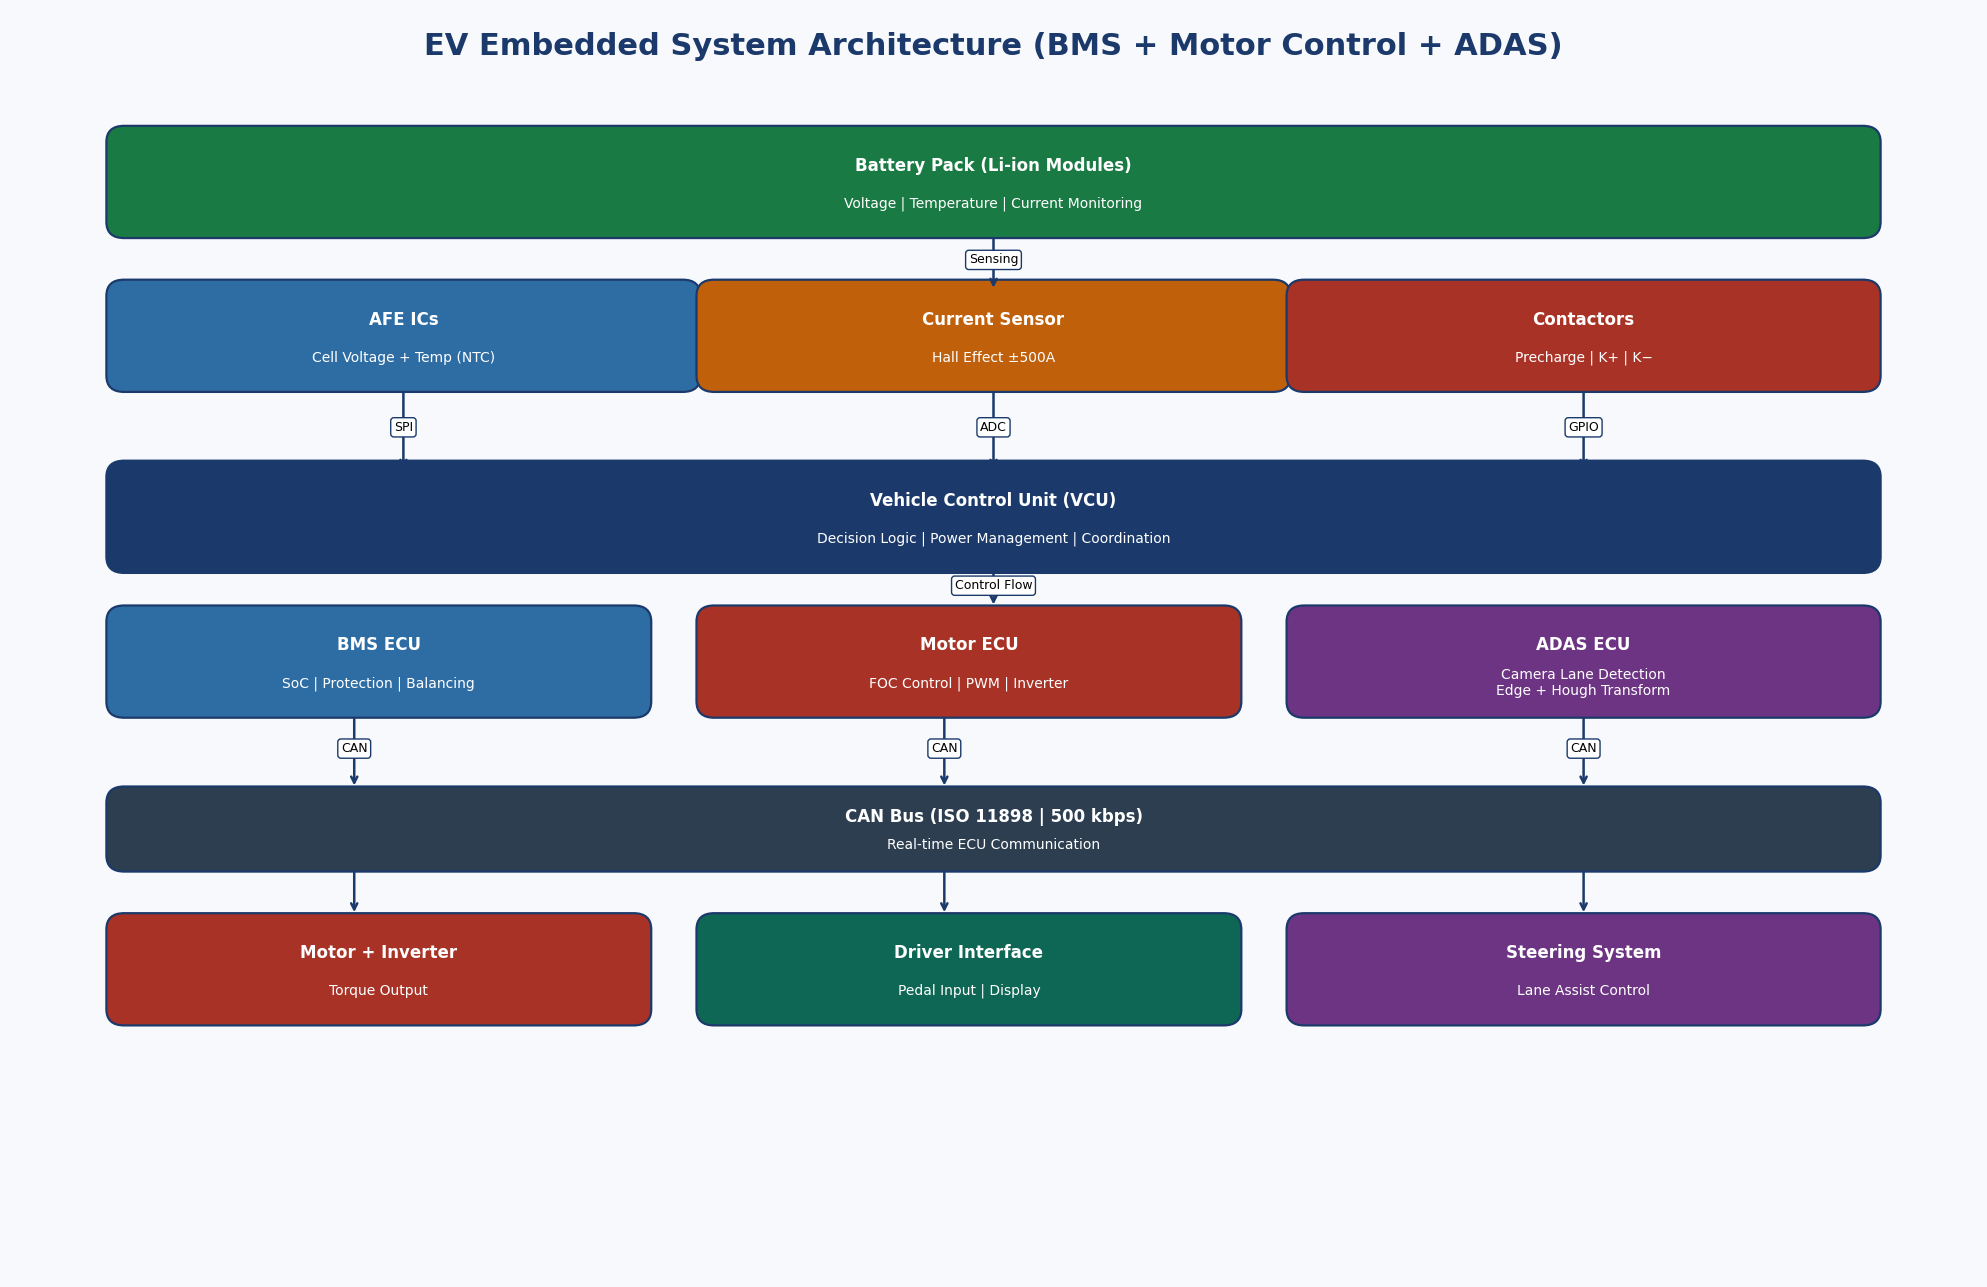

In [5]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch

# ─────────────────────────────────────────
# FIGURE SETUP (Professional Scaling)
# ─────────────────────────────────────────
fig, ax = plt.subplots(figsize=(20, 13))
ax.set_xlim(0, 20)
ax.set_ylim(0, 14)
ax.axis('off')

# Background
fig.patch.set_facecolor('#F7F9FC')
ax.set_facecolor('#F7F9FC')

# ─────────────────────────────────────────
# FONT SYSTEM (IMPORTANT)
# ─────────────────────────────────────────
TITLE_FS = 22
SECTION_FS = 12
BODY_FS = 10
LABEL_FS = 9

# ─────────────────────────────────────────
# COLORS
# ─────────────────────────────────────────
NAVY   = '#1B3A6B'
BLUE   = '#2E6DA4'
GREEN  = '#1A7A43'
ORANGE = '#C0600A'
RED    = '#A93226'
PURPLE = '#6C3483'
GRAY   = '#4D5656'
DGRAY  = '#2C3E50'
WHITE  = '#FFFFFF'
TEAL   = '#0E6655'

# ─────────────────────────────────────────
# BOX FUNCTION (Aligned + Clean)
# ─────────────────────────────────────────
def box(x, y, w, h, title, sub='', fc=BLUE):
    rect = FancyBboxPatch((x, y), w, h,
                          boxstyle="round,pad=0.02,rounding_size=0.18",
                          linewidth=1.6,
                          edgecolor=NAVY,
                          facecolor=fc)
    ax.add_patch(rect)

    ax.text(x+w/2, y+h*0.65, title,
            ha='center', va='center',
            fontsize=SECTION_FS,
            fontweight='bold',
            color=WHITE)

    if sub:
        ax.text(x+w/2, y+h*0.30, sub,
                ha='center', va='center',
                fontsize=BODY_FS,
                color=WHITE)

# ─────────────────────────────────────────
# ARROW FUNCTION
# ─────────────────────────────────────────
def arrow(x1, y1, x2, y2, label='', color=NAVY):
    ax.annotate('', xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle='->', lw=1.8, color=color))

    if label:
        ax.text((x1+x2)/2, (y1+y2)/2,
                label,
                fontsize=LABEL_FS,
                ha='center',
                bbox=dict(boxstyle='round,pad=0.25',
                          fc='white',
                          ec=color))

# ─────────────────────────────────────────
# TITLE
# ─────────────────────────────────────────
ax.text(10, 13.5,
        'EV Embedded System Architecture (BMS + Motor Control + ADAS)',
        ha='center', fontsize=TITLE_FS,
        fontweight='bold', color=NAVY)

# ─────────────────────────────────────────
# LAYER 1 — BATTERY
# ─────────────────────────────────────────
box(1, 11.5, 18, 1.2,
    'Battery Pack (Li-ion Modules)',
    'Voltage | Temperature | Current Monitoring',
    GREEN)

# ─────────────────────────────────────────
# LAYER 2 — HARDWARE SENSING
# ─────────────────────────────────────────
box(1, 9.8, 6, 1.2,
    'AFE ICs',
    'Cell Voltage + Temp (NTC)',
    BLUE)

box(7, 9.8, 6, 1.2,
    'Current Sensor',
    'Hall Effect ±500A',
    ORANGE)

box(13, 9.8, 6, 1.2,
    'Contactors',
    'Precharge | K+ | K−',
    RED)

# ─────────────────────────────────────────
# LAYER 3 — ECU CORE
# ─────────────────────────────────────────
box(1, 7.8, 18, 1.2,
    'Vehicle Control Unit (VCU)',
    'Decision Logic | Power Management | Coordination',
    NAVY)

# ─────────────────────────────────────────
# LAYER 4 — FUNCTIONAL ECUs
# ─────────────────────────────────────────
box(1, 6.2, 5.5, 1.2,
    'BMS ECU',
    'SoC | Protection | Balancing',
    BLUE)

box(7, 6.2, 5.5, 1.2,
    'Motor ECU',
    'FOC Control | PWM | Inverter',
    RED)

box(13, 6.2, 6, 1.2,
    'ADAS ECU',
    'Camera Lane Detection\nEdge + Hough Transform',
    PURPLE)

# ─────────────────────────────────────────
# LAYER 5 — CAN BUS
# ─────────────────────────────────────────
box(1, 4.5, 18, 0.9,
    'CAN Bus (ISO 11898 | 500 kbps)',
    'Real-time ECU Communication',
    DGRAY)

# ─────────────────────────────────────────
# LAYER 6 — EXTERNAL SYSTEMS
# ─────────────────────────────────────────
box(1, 2.8, 5.5, 1.2,
    'Motor + Inverter',
    'Torque Output',
    RED)

box(7, 2.8, 5.5, 1.2,
    'Driver Interface',
    'Pedal Input | Display',
    TEAL)

box(13, 2.8, 6, 1.2,
    'Steering System',
    'Lane Assist Control',
    PURPLE)

# ─────────────────────────────────────────
# CONNECTIONS
# ─────────────────────────────────────────
arrow(10,11.5,10,10.9,'Sensing')
arrow(4,9.8,4,8.9,'SPI')
arrow(10,9.8,10,8.9,'ADC')
arrow(16,9.8,16,8.9,'GPIO')

arrow(10,7.8,10,7.4,'Control Flow')

arrow(3.5,6.2,3.5,5.4,'CAN')
arrow(9.5,6.2,9.5,5.4,'CAN')
arrow(16,6.2,16,5.4,'CAN')

arrow(3.5,4.5,3.5,4.0)
arrow(9.5,4.5,9.5,4.0)
arrow(16,4.5,16,4.0)

# ─────────────────────────────────────────
# SAVE
# ─────────────────────────────────────────
plt.tight_layout()
plt.savefig("EV_Architecture_Industry.png",
            dpi=300,
            bbox_inches='tight')
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: '/home/claude/diag1_ev_arch.png'

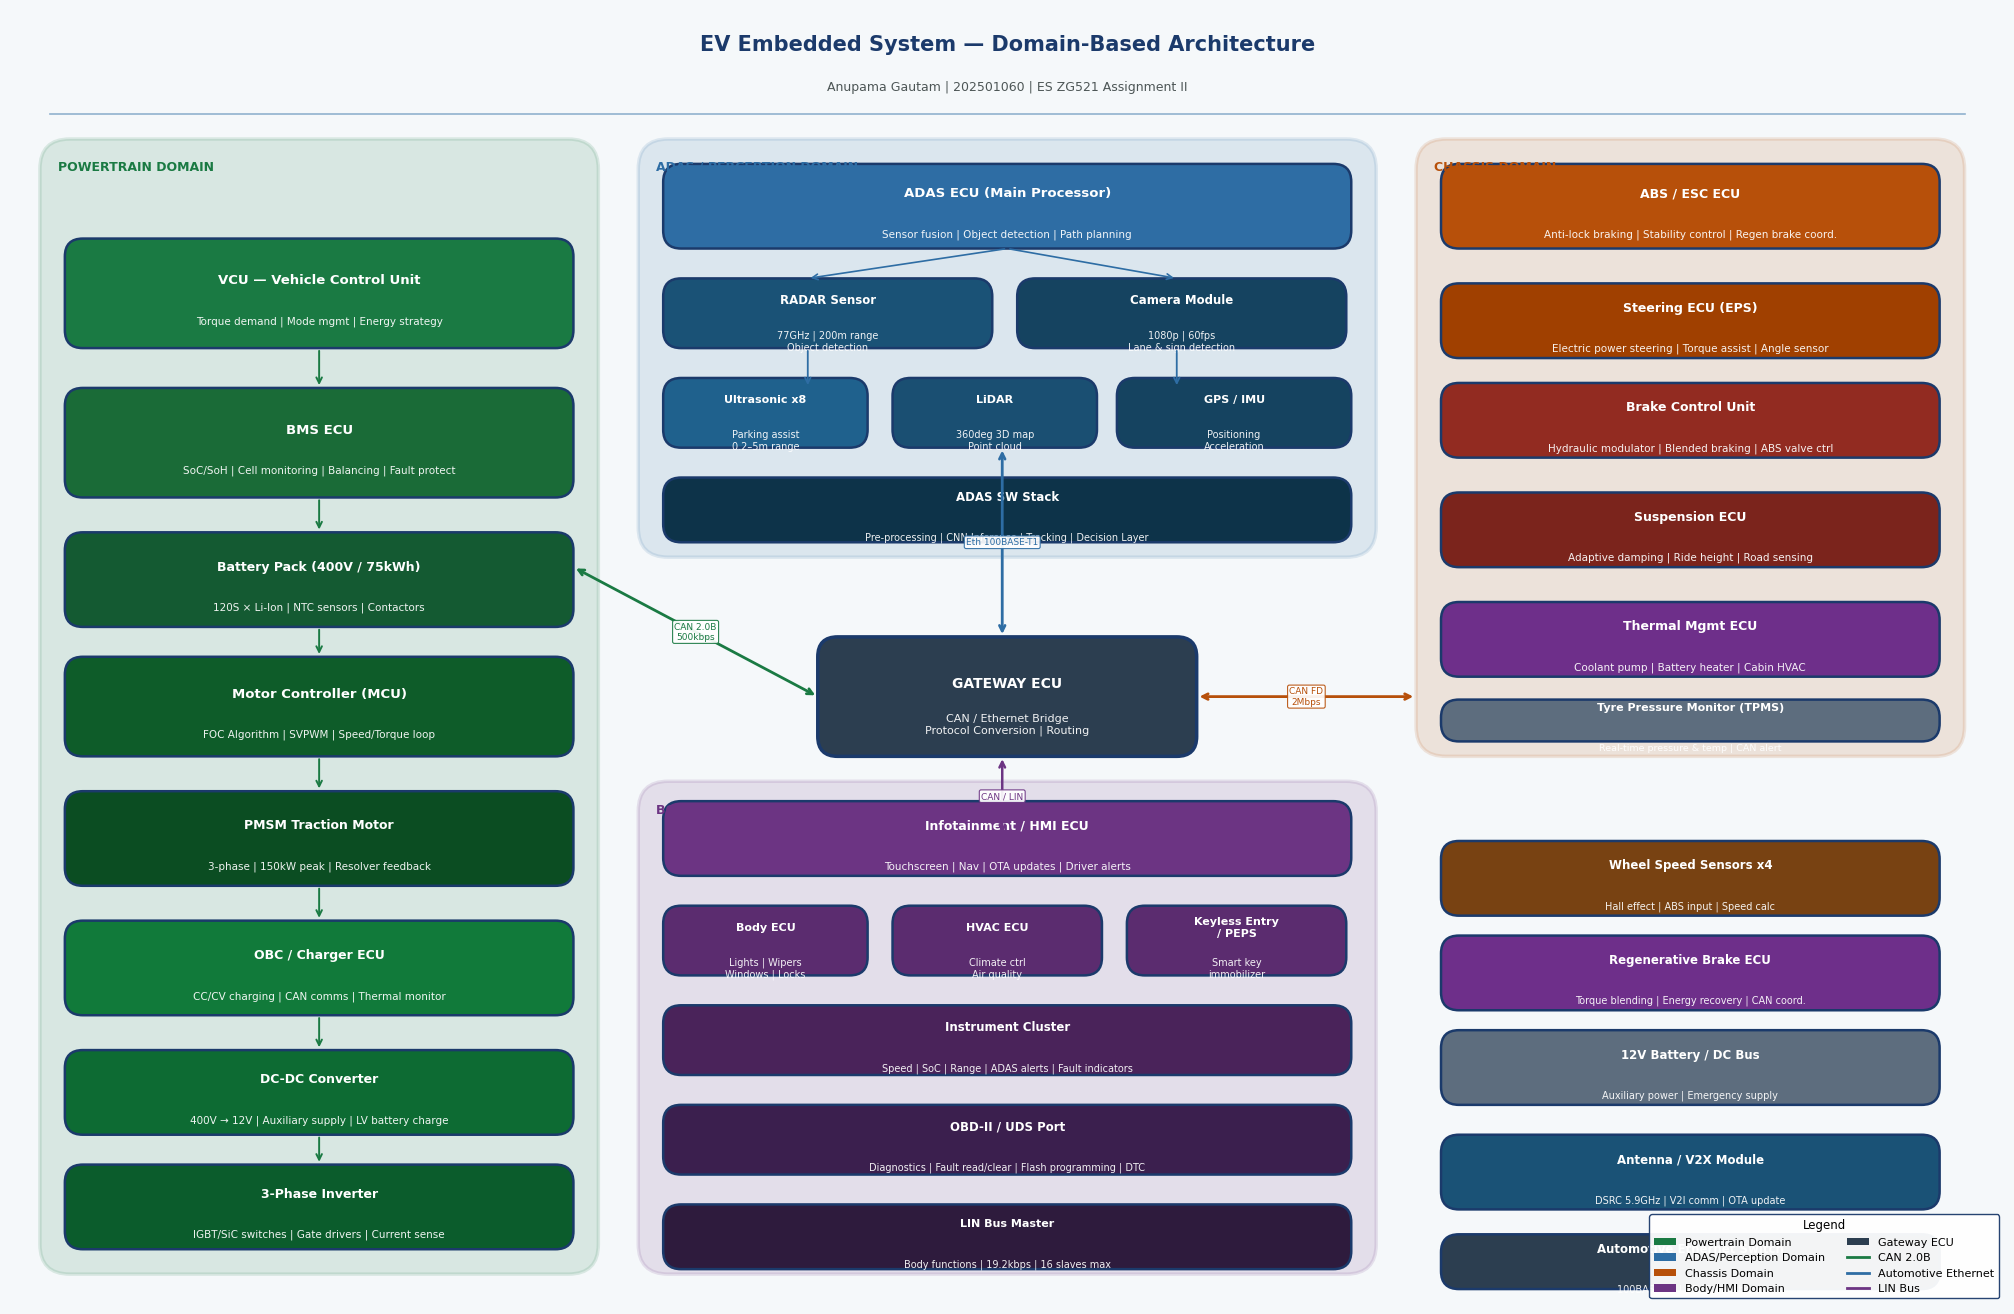

In [1]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch
import matplotlib.lines as mlines

fig, ax = plt.subplots(figsize=(20, 13))
ax.set_xlim(0, 20); ax.set_ylim(0, 13); ax.axis('off')
fig.patch.set_facecolor('#F5F8FA'); ax.set_facecolor('#F5F8FA')

NAVY='#1B3A6B'; BLUE='#2E6DA4'; GREEN='#1A7A43'; ORANGE='#B7500A'
RED='#922B21'; PURPLE='#6C3483'; TEAL='#0E6655'; GRAY='#4D5656'
DGRAY='#2C3E50'; WHITE='#FFFFFF'; LBLUE='#EAF2FB'

def rbox(x,y,w,h,title,sub='',fc=BLUE,tc=WHITE,fs=9,sfs=7.5,lw=1.8,r=0.18,ec=None):
    ec = ec or NAVY
    p = FancyBboxPatch((x,y),w,h,boxstyle=f"round,pad=0,rounding_size={r}",
                        linewidth=lw,edgecolor=ec,facecolor=fc,zorder=3)
    ax.add_patch(p)
    cy = y+h/2+(0.13 if sub else 0)
    ax.text(x+w/2,cy,title,ha='center',va='center',fontsize=fs,fontweight='bold',
            color=tc,zorder=5,multialignment='center')
    if sub:
        ax.text(x+w/2,y+h/2-0.28,sub,ha='center',va='center',fontsize=sfs,
                color=tc,zorder=5,multialignment='center',alpha=0.93)

def arr(x1,y1,x2,y2,lbl='',col=NAVY,lw=1.6,bi=False,lsty='solid'):
    sty='<->' if bi else '->'
    ax.annotate('',xy=(x2,y2),xytext=(x1,y1),zorder=6,
                arrowprops=dict(arrowstyle=sty,color=col,lw=lw,linestyle=lsty,
                                connectionstyle='arc3,rad=0'))
    if lbl:
        mx,my=(x1+x2)/2,(y1+y2)/2
        ax.text(mx,my,lbl,fontsize=6.5,color=col,ha='center',va='center',
                bbox=dict(boxstyle='round,pad=0.2',fc='white',ec=col,alpha=0.92,lw=0.8),zorder=7)

def domain_box(x,y,w,h,title,color,alpha=0.13):
    p = FancyBboxPatch((x,y),w,h,boxstyle="round,pad=0,rounding_size=0.3",
                        linewidth=2.5,edgecolor=color,facecolor=color,alpha=alpha,zorder=1)
    ax.add_patch(p)
    ax.text(x+0.18,y+h-0.28,title,fontsize=9,fontweight='bold',color=color,va='center',zorder=5)

# ─── TITLE ────────────────────────────────────────────────────────────────────
ax.text(10,12.65,'EV Embedded System — Domain-Based Architecture',
        ha='center',va='center',fontsize=15,fontweight='bold',color=NAVY)
ax.text(10,12.22,'Anupama Gautam | 202501060 | ES ZG521 Assignment II',
        ha='center',va='center',fontsize=9,color=GRAY)
ax.plot([0.4,19.6],[11.95,11.95],color=BLUE,lw=1.2,alpha=0.5)

# ─── CENTRAL GATEWAY ECU ─────────────────────────────────────────────────────
rbox(8.1,5.5,3.8,1.2,'GATEWAY ECU','CAN / Ethernet Bridge\nProtocol Conversion | Routing',
     fc=DGRAY,tc=WHITE,fs=10,sfs=8,lw=2.5,r=0.2)

# ─── DOMAIN 1: POWERTRAIN ─────────────────────────────────────────────────────
domain_box(0.3,0.3,5.6,11.4,'POWERTRAIN DOMAIN',GREEN)
# VCU
rbox(0.55,9.6,5.1,1.1,'VCU — Vehicle Control Unit','Torque demand | Mode mgmt | Energy strategy',fc=GREEN,fs=9.5,sfs=7.5)
# BMS ECU
rbox(0.55,8.1,5.1,1.1,'BMS ECU','SoC/SoH | Cell monitoring | Balancing | Fault protect',fc='#1A6B37',fs=9.5,sfs=7.5)
# Battery Pack
rbox(0.55,6.8,5.1,0.95,'Battery Pack (400V / 75kWh)','120S × Li-Ion | NTC sensors | Contactors',fc='#145A32',fs=9,sfs=7.5)
# Motor Controller
rbox(0.55,5.5,5.1,1.0,'Motor Controller (MCU)','FOC Algorithm | SVPWM | Speed/Torque loop',fc='#0E5C29',fs=9.5,sfs=7.5)
# PMSM Motor
rbox(0.55,4.2,5.1,0.95,'PMSM Traction Motor','3-phase | 150kW peak | Resolver feedback',fc='#0B4D22',fs=9,sfs=7.5)
# Charger ECU
rbox(0.55,2.9,5.1,0.95,'OBC / Charger ECU','CC/CV charging | CAN comms | Thermal monitor',fc='#117A3A',fs=9,sfs=7.5)
# DC-DC
rbox(0.55,1.7,5.1,0.85,'DC-DC Converter','400V → 12V | Auxiliary supply | LV battery charge',fc='#0D6B33',fs=9,sfs=7.5)
# Inverter
rbox(0.55,0.55,5.1,0.85,'3-Phase Inverter','IGBT/SiC switches | Gate drivers | Current sense',fc='#0B5C2C',fs=9,sfs=7.5)

# ─── DOMAIN 2: ADAS / PERCEPTION ─────────────────────────────────────────────
domain_box(6.3,7.5,7.4,4.2,'ADAS / PERCEPTION DOMAIN',BLUE)
rbox(6.55,10.6,6.9,0.85,'ADAS ECU (Main Processor)','Sensor fusion | Object detection | Path planning',fc=BLUE,fs=9.5,sfs=7.5)
rbox(6.55,9.6,3.3,0.7,'RADAR Sensor','77GHz | 200m range\nObject detection',fc='#1A5276',fs=8.5,sfs=7)
rbox(10.1,9.6,3.3,0.7,'Camera Module','1080p | 60fps\nLane & sign detection',fc='#154360',fs=8.5,sfs=7)
rbox(6.55,8.6,2.05,0.7,'Ultrasonic x8','Parking assist\n0.2–5m range',fc='#1F618D',fs=8,sfs=7)
rbox(8.85,8.6,2.05,0.7,'LiDAR','360deg 3D map\nPoint cloud',fc='#1A4F72',fs=8,sfs=7)
rbox(11.1,8.6,2.35,0.7,'GPS / IMU','Positioning\nAcceleration',fc='#154360',fs=8,sfs=7)
rbox(6.55,7.65,6.9,0.65,'ADAS SW Stack','Pre-processing | CNN Inference | Tracking | Decision Layer',fc='#0D3349',fs=8.5,sfs=7)

# ─── DOMAIN 3: CHASSIS ────────────────────────────────────────────────────────
domain_box(14.1,5.5,5.5,6.2,'CHASSIS DOMAIN',ORANGE)
rbox(14.35,10.6,5.0,0.85,'ABS / ESC ECU','Anti-lock braking | Stability control | Regen brake coord.',fc=ORANGE,fs=9,sfs=7.5)
rbox(14.35,9.5,5.0,0.75,'Steering ECU (EPS)','Electric power steering | Torque assist | Angle sensor',fc='#A04000',fs=9,sfs=7.5)
rbox(14.35,8.5,5.0,0.75,'Brake Control Unit','Hydraulic modulator | Blended braking | ABS valve ctrl',fc='#922B21',fs=9,sfs=7.5)
rbox(14.35,7.4,5.0,0.75,'Suspension ECU','Adaptive damping | Ride height | Road sensing',fc='#7B241C',fs=9,sfs=7.5)
rbox(14.35,6.3,5.0,0.75,'Thermal Mgmt ECU','Coolant pump | Battery heater | Cabin HVAC',fc='#6E2F8A',fs=9,sfs=7.5)
rbox(14.35,5.65,5.0,0.42,'Tyre Pressure Monitor (TPMS)','Real-time pressure & temp | CAN alert',fc='#5D6D7E',fs=8,sfs=6.8)

# ─── DOMAIN 4: BODY / HMI ─────────────────────────────────────────────────────
domain_box(0.3,0.3,19.3,0.3,'',WHITE,alpha=0)  # spacer
domain_box(6.3,0.3,7.4,4.95,'BODY / HMI DOMAIN',PURPLE)
rbox(6.55,4.3,6.9,0.75,'Infotainment / HMI ECU','Touchscreen | Nav | OTA updates | Driver alerts',fc=PURPLE,fs=9,sfs=7.5)
rbox(6.55,3.3,2.05,0.7,'Body ECU','Lights | Wipers\nWindows | Locks',fc='#5B2C6F',fs=8,sfs=7)
rbox(8.85,3.3,2.1,0.7,'HVAC ECU','Climate ctrl\nAir quality',fc='#5B2C6F',fs=8,sfs=7)
rbox(11.2,3.3,2.2,0.7,'Keyless Entry\n/ PEPS','Smart key\nimmobilizer',fc='#5B2C6F',fs=8,sfs=7)
rbox(6.55,2.3,6.9,0.7,'Instrument Cluster','Speed | SoC | Range | ADAS alerts | Fault indicators',fc='#4A235A',fs=8.5,sfs=7)
rbox(6.55,1.3,6.9,0.7,'OBD-II / UDS Port','Diagnostics | Fault read/clear | Flash programming | DTC',fc='#3B1F4E',fs=8.5,sfs=7)
rbox(6.55,0.35,6.9,0.65,'LIN Bus Master','Body functions | 19.2kbps | 16 slaves max',fc='#2E1B3D',fs=8,sfs=7)

# ─── DOMAIN 5: CHASSIS (right bottom) ────────────────────────────────────────
domain_box(14.1,0.3,5.5,5.0,'',ORANGE,alpha=0)
rbox(14.35,3.9,5.0,0.75,'Wheel Speed Sensors x4','Hall effect | ABS input | Speed calc',fc='#784212',fs=8.5,sfs=7)
rbox(14.35,2.95,5.0,0.75,'Regenerative Brake ECU','Torque blending | Energy recovery | CAN coord.',fc='#6E2F8A',fs=8.5,sfs=7)
rbox(14.35,2.0,5.0,0.75,'12V Battery / DC Bus','Auxiliary power | Emergency supply',fc='#5D6D7E',fs=8.5,sfs=7)
rbox(14.35,0.95,5.0,0.75,'Antenna / V2X Module','DSRC 5.9GHz | V2I comm | OTA update',fc='#1A5276',fs=8.5,sfs=7)
rbox(14.35,0.15,5.0,0.55,'Automotive Ethernet Switch','100BASE-T1 | ADAS backbone',fc=DGRAY,fs=8.5,sfs=7)

# ─── GATEWAY CONNECTIONS ──────────────────────────────────────────────────────
# Powertrain ↔ Gateway
arr(5.65,7.4,8.1,6.1,'CAN 2.0B\n500kbps',GREEN,lw=2.0,bi=True)
# ADAS ↔ Gateway
arr(9.95,8.6,9.95,6.7,'Eth 100BASE-T1',BLUE,lw=2.0,bi=True)
# Chassis ↔ Gateway
arr(14.1,6.1,11.9,6.1,'CAN FD\n2Mbps',ORANGE,lw=2.0,bi=True)
# Body ↔ Gateway
arr(9.95,7.5,9.95,6.7,'',BLUE,lw=0,bi=False)
arr(9.95,5.5,9.95,4.7,'CAN / LIN',PURPLE,lw=1.8,bi=True)

# Internal domain arrows (sample)
arr(3.1,9.6,3.1,9.2,'',GREEN,lw=1.4)
arr(3.1,8.1,3.1,7.75,'',GREEN,lw=1.4)
arr(3.1,6.8,3.1,6.5,'',GREEN,lw=1.4)
arr(3.1,5.5,3.1,5.15,'',GREEN,lw=1.4)
arr(3.1,4.2,3.1,3.85,'',GREEN,lw=1.4)
arr(3.1,2.9,3.1,2.55,'',GREEN,lw=1.4)
arr(3.1,1.7,3.1,1.4,'',GREEN,lw=1.4)

# ADAS internal
arr(10.0,10.6,8.0,10.3,'',BLUE,lw=1.2)
arr(10.0,10.6,11.7,10.3,'',BLUE,lw=1.2)
arr(8.0,9.6,8.0,9.2,'',BLUE,lw=1.3)
arr(11.7,9.6,11.7,9.2,'',BLUE,lw=1.3)

# LEGEND
legend_items = [
    mpatches.Patch(facecolor=GREEN,label='Powertrain Domain'),
    mpatches.Patch(facecolor=BLUE,label='ADAS/Perception Domain'),
    mpatches.Patch(facecolor=ORANGE,label='Chassis Domain'),
    mpatches.Patch(facecolor=PURPLE,label='Body/HMI Domain'),
    mpatches.Patch(facecolor=DGRAY,label='Gateway ECU'),
    mlines.Line2D([],[],color=GREEN,lw=2,label='CAN 2.0B'),
    mlines.Line2D([],[],color=BLUE,lw=2,label='Automotive Ethernet'),
    mlines.Line2D([],[],color=PURPLE,lw=2,label='LIN Bus'),
]
ax.legend(handles=legend_items,loc='lower right',fontsize=8,framealpha=0.95,
          edgecolor=NAVY,ncol=2,bbox_to_anchor=(1.0,0.0),title='Legend',title_fontsize=8.5)

plt.tight_layout(pad=0.2)
plt.savefig('/home/claude/diag1_ev_arch.png',dpi=200,bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.close()
print("Diagram 1 saved.")
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch
import matplotlib.lines as mlines

fig, ax = plt.subplots(figsize=(20, 11))
ax.set_xlim(0, 20); ax.set_ylim(0, 11); ax.axis('off')
fig.patch.set_facecolor('#F5F8FA'); ax.set_facecolor('#F5F8FA')

NAVY='#1B3A6B'; BLUE='#2E6DA4'; GREEN='#1A7A43'; ORANGE='#B7500A'
RED='#922B21'; PURPLE='#6C3483'; TEAL='#0E6655'; GRAY='#4D5656'
DGRAY='#2C3E50'; WHITE='#FFFFFF'; LGREEN='#E8F8F0'

def rbox(x,y,w,h,title,sub='',fc=BLUE,tc=WHITE,fs=9,sfs=7.5,lw=1.8,r=0.16):
    p = FancyBboxPatch((x,y),w,h,boxstyle=f"round,pad=0,rounding_size={r}",
                        linewidth=lw,edgecolor=NAVY,facecolor=fc,zorder=3)
    ax.add_patch(p)
    cy = y+h/2+(0.12 if sub else 0)
    ax.text(x+w/2,cy,title,ha='center',va='center',fontsize=fs,fontweight='bold',
            color=tc,zorder=5,multialignment='center')
    if sub:
        ax.text(x+w/2,y+h/2-0.26,sub,ha='center',va='center',fontsize=sfs,
                color=tc,zorder=5,multialignment='center',alpha=0.92)

def arr(x1,y1,x2,y2,lbl='',col=NAVY,lw=1.6,bi=False):
    sty='<->' if bi else '->'
    ax.annotate('',xy=(x2,y2),xytext=(x1,y1),zorder=6,
                arrowprops=dict(arrowstyle=sty,color=col,lw=lw,
                                connectionstyle='arc3,rad=0'))
    if lbl:
        mx,my=(x1+x2)/2,(y1+y2)/2
        ax.text(mx,my,lbl,fontsize=6.5,color=col,ha='center',va='center',
                bbox=dict(boxstyle='round,pad=0.18',fc='white',ec=col,alpha=0.92,lw=0.8),zorder=7)

# ─── TITLE ───────────────────────────────────────────────────────────────────
ax.text(10,10.7,'Task 2: Battery Management System (BMS) — Design Architecture',
        ha='center',va='center',fontsize=13,fontweight='bold',color=NAVY)
ax.plot([0.4,19.6],[10.42,10.42],color=BLUE,lw=1.2,alpha=0.5)

# ─── BATTERY PACK (top) ───────────────────────────────────────────────────────
bp = FancyBboxPatch((0.4,9.05),19.2,1.1,boxstyle="round,pad=0,rounding_size=0.22",
                     linewidth=2.5,edgecolor=GREEN,facecolor='#E8F8F0',zorder=2)
ax.add_patch(bp)
ax.text(2.0,9.62,'BATTERY PACK  —  120S × Li-Ion  |  400V / 75kWh  |  10 Modules × 12 Cells',
        ha='center',va='center',fontsize=9.5,fontweight='bold',color=GREEN)
# Individual modules
for i in range(10):
    mx = 0.55 + i*1.91
    rbox(mx,9.12,1.72,0.78,f'M{i+1}','12S Li-Ion',fc=GREEN,tc=WHITE,fs=8,sfs=6.8,r=0.12)

# ─── SENSING LAYER ────────────────────────────────────────────────────────────
rbox(0.4,7.75,5.8,0.95,'Cell Voltage Measurement','LTC6812-1 AFE × 10 ICs | 16-bit ADC | ±5mV | isoSPI daisy-chain',
     fc=BLUE,tc=WHITE,fs=9,sfs=7.5)
rbox(6.5,7.75,5.8,0.95,'Temperature Measurement','NTC Thermistors × 30 sensors | 3 per module | ±1°C accuracy',
     fc='#1A5276',tc=WHITE,fs=9,sfs=7.5)
rbox(12.6,7.75,7.0,0.95,'Current Measurement','Hall-Effect Sensor (±500A) | Isolated | 16-bit ADC | Coulomb accumulator',
     fc='#0D3349',tc=WHITE,fs=9,sfs=7.5)

# Arrows sensing → ECU
arr(3.3,7.75,3.3,6.75,'Cell V',BLUE,lw=1.8)
arr(9.4,7.75,9.4,6.75,'Temp',TEAL,lw=1.8)
arr(16.1,7.75,16.1,6.75,'Current',DGRAY,lw=1.8)

# ─── BMS ECU BOX ─────────────────────────────────────────────────────────────
ecu_bg = FancyBboxPatch((0.4,3.45),19.2,3.05,boxstyle="round,pad=0,rounding_size=0.28",
                          linewidth=2.8,edgecolor=NAVY,facecolor='#EAF2FB',zorder=2)
ax.add_patch(ecu_bg)
ax.text(10,6.28,'BMS ECU  —  STM32F4 Cortex-M4 | FreeRTOS | MISRA-C:2012',
        ha='center',va='center',fontsize=10.5,fontweight='bold',color=NAVY)

# ─── THREE COLUMNS inside ECU ─────────────────────────────────────────────────
# COL 1: SoC / SoH Estimation
rbox(0.6,5.15,5.9,0.95,'SoC Estimation Module','Coulomb Counting (primary) + OCV Lookup (rest correction)\nKalman Filter for noise rejection | Error < ±3%',
     fc='#154360',tc=WHITE,fs=8.5,sfs=7.2)
rbox(0.6,3.95,5.9,0.9,'SoH Estimation Module','Cycle count | Capacity fade tracking\nInternal resistance rise detection',
     fc='#0D3349',tc=WHITE,fs=8.5,sfs=7.2)

# COL 2: Protection
rbox(6.85,5.15,6.3,0.95,'Fault Detection Engine','Over-Voltage (>4.25V) | Under-Voltage (<2.5V)\nOver-Temp (>60°C) | Over-Current (>350A) | Short Circuit',
     fc=RED,tc=WHITE,fs=8.5,sfs=7.2)
rbox(6.85,3.95,6.3,0.9,'Contactor State Machine','Pre-charge → K+ → K− sequence\nWeld detection | Inrush protection | <5V diff check',
     fc='#7B241C',tc=WHITE,fs=8.5,sfs=7.2)

# COL 3: Balancing
rbox(13.45,5.15,5.95,0.95,'Cell Balancing Controller','Passive Balancing: bleed resistors on high-V cells\nCharge-phase only | AFE balance pins | ±10mV target',
     fc=GREEN,tc=WHITE,fs=8.5,sfs=7.2)
rbox(13.45,3.95,5.95,0.9,'Communication Manager','CAN 2.0B @ 500kbps | 100ms broadcast\nUDS ISO14229 diagnostics | SPI Flash fault log',
     fc=TEAL,tc=WHITE,fs=8.5,sfs=7.2)

# ─── SoC METHOD DETAIL ───────────────────────────────────────────────────────
soc_bg = FancyBboxPatch((0.4,0.3),9.0,3.0,boxstyle="round,pad=0,rounding_size=0.2",
                          linewidth=1.8,edgecolor=BLUE,facecolor='#EAF2FB',zorder=2)
ax.add_patch(soc_bg)
ax.text(4.9,3.12,'SoC Estimation — Coulomb Counting + OCV Fusion',
        ha='center',va='center',fontsize=9.5,fontweight='bold',color=NAVY)

# CC flow
steps_cc = [
    (0.6,2.25,2.2,0.62,'Measure\nCurrent I(t)','Hall sensor ADC',BLUE),
    (3.1,2.25,2.2,0.62,'Integrate\nQ = ∫I dt','Discrete sum\n100ms sample',BLUE),
    (5.6,2.25,2.2,0.62,'Compute\nSoC(CC)','SoC = SoC0\n- Q/Q_rated','#154360'),
    (0.6,1.35,2.2,0.62,'OCV Lookup\nTable','At rest state\n(I ≈ 0)','#1A7A43'),
    (3.1,1.35,2.2,0.62,'Correction\nSoC(OCV)','Map OCV →\nSoC lookup','#1A7A43'),
    (5.6,1.35,2.2,0.62,'Fusion &\nKalman Filter','Weighted blend\nDrift correction',TEAL),
    (8.1,1.7,1.1,1.2,'Final\nSoC %','0–100%\n±3% error',GREEN),
]
for (bx,by,bw,bh,t,s,c) in steps_cc:
    rbox(bx,by,bw,bh,t,s,fc=c,tc=WHITE,fs=8,sfs=6.8,lw=1.2,r=0.12)
# arrows between steps
arr(2.8,2.56,3.1,2.56,'',BLUE,lw=1.4)
arr(5.3,2.56,5.6,2.56,'',BLUE,lw=1.4)
arr(2.8,1.66,3.1,1.66,'',GREEN,lw=1.4)
arr(5.3,1.66,5.6,1.66,'',GREEN,lw=1.4)
arr(7.8,1.66,8.1,1.66,'',TEAL,lw=1.5)
arr(3.5,2.25,3.5,1.97,'',GRAY,lw=1.2)  # CC feeds fusion

# ─── PROTECTION DETAIL ────────────────────────────────────────────────────────
prot_bg = FancyBboxPatch((9.8,0.3),9.8,3.0,boxstyle="round,pad=0,rounding_size=0.2",
                           linewidth=1.8,edgecolor=RED,facecolor='#FDEDEC',zorder=2)
ax.add_patch(prot_bg)
ax.text(14.7,3.12,'Protection Mechanisms & Cell Balancing Strategy',
        ha='center',va='center',fontsize=9.5,fontweight='bold',color=NAVY)

faults=[
    (10.0,2.2,'Over-Voltage','> 4.25V/cell','Open K+/K−\nStop charge',RED),
    (12.25,2.2,'Under-Voltage','< 2.5V/cell','Open K+/K−\nLoad shed',RED),
    (14.5,2.2,'Over-Temp','> 60°C cells','De-rate I\n>70°C → trip','#8B0000'),
    (16.75,2.2,'Over-Current','> 350A','Trip < 5ms\nLatch fault',RED),
    (10.0,0.95,'Under-Temp','< -20°C','Block charge\n20% I limit','#5D6D7E'),
    (12.25,0.95,'Short Circuit','ΔV spike','HW trip < 1ms\nFuse blow','#8B0000'),
    (14.5,0.95,'Passive Balance','High-V cells','Bleed resistor\nCharge phase',GREEN),
    (16.75,0.95,'Active Balance','Cells mismatch','Switched cap.\n(Future ext.)',TEAL),
]
for (fx,fy,ft,fcond,fres,fclr) in faults:
    rbox(fx,fy,2.0,0.95,ft,f'{fcond}\n→ {fres}',fc=fclr,tc=WHITE,fs=8,sfs=6.8,lw=1.2,r=0.12)

# Arrows ECU → contactors area
arr(3.5,3.45,3.5,3.05,'SoC out',BLUE,lw=1.5)
arr(10.0,3.45,10.0,3.05,'Fault flags',RED,lw=1.5)
arr(16.4,3.45,16.4,3.05,'Balance cmd',GREEN,lw=1.5)

plt.tight_layout(pad=0.2)
plt.savefig('/home/claude/diag2_bms.png',dpi=200,bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.close()
print("Diagram 2 saved.")
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch

fig, ax = plt.subplots(figsize=(20, 9))
ax.set_xlim(0, 20); ax.set_ylim(0, 9); ax.axis('off')
fig.patch.set_facecolor('#F5F8FA')

NAVY='#1B3A6B'; BLUE='#2E6DA4'; GREEN='#1A7A43'; ORANGE='#B7500A'
RED='#922B21'; PURPLE='#6C3483'; TEAL='#0E6655'; GRAY='#4D5656'
DGRAY='#2C3E50'; WHITE='#FFFFFF'

def rbox(x,y,w,h,title,sub='',fc=BLUE,tc=WHITE,fs=9,sfs=7.5,lw=1.8,r=0.15):
    p = FancyBboxPatch((x,y),w,h,boxstyle=f"round,pad=0,rounding_size={r}",
                        linewidth=lw,edgecolor=NAVY,facecolor=fc,zorder=3)
    ax.add_patch(p)
    cy = y+h/2+(0.11 if sub else 0)
    ax.text(x+w/2,cy,title,ha='center',va='center',fontsize=fs,fontweight='bold',
            color=tc,zorder=5,multialignment='center')
    if sub:
        ax.text(x+w/2,y+h/2-0.24,sub,ha='center',va='center',fontsize=sfs,
                color=tc,zorder=5,multialignment='center',alpha=0.92)

def arr(x1,y1,x2,y2,lbl='',col=NAVY,lw=1.6,bi=False):
    sty='<->' if bi else '->'
    ax.annotate('',xy=(x2,y2),xytext=(x1,y1),zorder=6,
                arrowprops=dict(arrowstyle=sty,color=col,lw=lw,connectionstyle='arc3,rad=0'))
    if lbl:
        mx,my=(x1+x2)/2,(y1+y2)/2
        ax.text(mx,my,lbl,fontsize=6.5,color=col,ha='center',va='center',
                bbox=dict(boxstyle='round,pad=0.18',fc='white',ec=col,alpha=0.92,lw=0.8),zorder=7)

def diamond(x,y,w,h,txt,col=ORANGE):
    dx,dy=w/2,h/2
    cx,cy=x+dx,y+dy
    pts=[[cx,y+h],[x+w,cy],[cx,y],[x,cy]]
    patch=plt.Polygon(pts,closed=True,facecolor=col,edgecolor=NAVY,lw=1.5,zorder=3)
    ax.add_patch(patch)
    ax.text(cx,cy,txt,ha='center',va='center',fontsize=7.5,fontweight='bold',color=WHITE,zorder=5)

# ─── TITLE ────────────────────────────────────────────────────────────────────
ax.text(10,8.72,'Task 3: PMSM Motor Drive Control — Field Oriented Control (FOC) Architecture',
        ha='center',va='center',fontsize=13,fontweight='bold',color=NAVY)
ax.plot([0.3,19.7],[8.45,8.45],color=BLUE,lw=1.2,alpha=0.5)

# ─── TOP ROW: DRIVER INPUT ────────────────────────────────────────────────────
rbox(0.3,7.15,3.2,0.95,'Driver Input','Accelerator pedal | Brake pedal\nReverse / Drive / Regen mode',fc=PURPLE,fs=9,sfs=7.5)
rbox(3.85,7.15,3.2,0.95,'VCU — Torque Demand','Torque request calc.\nSpeed limits | Mode arbitration',fc='#5B2C6F',fs=9,sfs=7.5)
rbox(7.4,7.15,2.5,0.95,'Speed\nReference ω*','Target RPM\nfrom VCU',fc=NAVY,fs=9,sfs=7.5)
rbox(10.2,7.15,2.5,0.95,'Speed PI\nController','PI: Kp, Ki\nSpeed error',fc='#154360',fs=9,sfs=7.5)
rbox(13.0,7.15,3.0,0.95,'Current\nReference (Id*,Iq*)','Id*=0 (MTPA)\nIq* = torque demand',fc='#1A5276',fs=9,sfs=7.5)
rbox(16.3,7.15,3.4,0.95,'PMSM Motor','150kW | 400Nm | 12000 RPM\n3-phase | Resolver feedback',fc=GREEN,fs=9,sfs=7.5)

# top row arrows
arr(3.5,7.62,3.85,7.62,'Pedal pos.',PURPLE,lw=1.5)
arr(7.05,7.62,7.4,7.62,'Demand',PURPLE,lw=1.5)
arr(9.9,7.62,10.2,7.62,'ω*',NAVY,lw=1.5)
arr(12.7,7.62,13.0,7.62,'Iq*',NAVY,lw=1.5)
arr(16.0,7.62,16.3,7.62,'',GREEN,lw=1.5)

# ─── FOC CONTROL LOOP (main block) ────────────────────────────────────────────
foc_bg = FancyBboxPatch((0.3,1.5),19.4,5.3,boxstyle="round,pad=0,rounding_size=0.28",
                          linewidth=2.5,edgecolor=NAVY,facecolor='#EAF2FB',zorder=2)
ax.add_patch(foc_bg)
ax.text(10,6.6,'Field Oriented Control (FOC) — Current Control Loop',
        ha='center',va='center',fontsize=10.5,fontweight='bold',color=NAVY)

# ROW 1 of FOC: reference comparison
rbox(0.6,5.5,2.2,0.85,'Sum Junction\n(Id error)','Id* - Id_meas',fc='#154360',fs=8,sfs=7)
rbox(3.1,5.5,2.5,0.85,'d-axis PI\nController','Vd command\nBandwidth 1kHz',fc='#1A5276',fs=8,sfs=7)
rbox(5.9,5.5,2.5,0.85,'Sum Junction\n(Iq error)','Iq* - Iq_meas',fc='#154360',fs=8,sfs=7)
rbox(8.65,5.5,2.5,0.85,'q-axis PI\nController','Vq command\nBandwidth 1kHz',fc='#1A5276',fs=8,sfs=7)

# dq → αβ transform
rbox(11.45,5.5,2.7,0.85,'Inverse Park\nTransform','(Vd,Vq) → (Vα,Vβ)\nRotation by θ_e',fc=ORANGE,fs=8,sfs=7)
rbox(14.4,5.5,2.7,0.85,'Space Vector\nPWM (SVPWM)','Duty cycles\n20kHz carrier',fc='#A04000',fs=8,sfs=7)
rbox(17.3,5.5,2.0,0.85,'3-Phase\nInverter','SiC MOSFETs\n6-switch bridge',fc=RED,fs=8,sfs=7)

arr(2.8,5.92,3.1,5.92,'',NAVY,lw=1.5)
arr(5.6,5.92,5.9,5.92,'',NAVY,lw=1.5)
arr(8.35,5.92,8.65,5.92,'',NAVY,lw=1.5)
arr(11.15,5.92,11.45,5.92,'Vd,Vq',NAVY,lw=1.5)
arr(14.1,5.92,14.4,5.92,'Vα,Vβ',ORANGE,lw=1.5)
arr(17.1,5.92,17.3,5.92,'PWM',ORANGE,lw=1.5)

# ROW 2: Feedback path
rbox(0.6,4.2,2.5,0.85,'Clark Transform','(Ia,Ib,Ic)→(Iα,Iβ)\n3→2 phase',fc=TEAL,fs=8.5,sfs=7.2)
rbox(3.4,4.2,2.5,0.85,'Park Transform','(Iα,Iβ)→(Id,Iq)\nRotation by θ_e',fc='#0E6655',fs=8.5,sfs=7.2)
rbox(6.2,4.2,2.5,0.85,'Current Sensor\n(3-phase)','Shunt/Hall sensors\nId, Iq measurement',fc='#0B5C4E',fs=8.5,sfs=7.2)
rbox(9.1,4.2,2.5,0.85,'Resolver /\nEncoder','θ_e, ω_meas.\n16-bit position',fc='#117A65',fs=8.5,sfs=7.2)
rbox(11.9,4.2,2.5,0.85,'Speed\nCalculation','ω = dθ/dt\nFiltered estimate',fc='#0E6655',fs=8.5,sfs=7.2)
rbox(14.7,4.2,2.5,0.85,'Thermal\nMonitor','NTC on motor\nwinding | De-rate',fc='#922B21',fs=8.5,sfs=7.2)
rbox(17.5,4.2,1.8,0.85,'PMSM','3-phase\nLoad',fc=GREEN,fs=9,sfs=7)

arr(3.1,4.62,3.4,4.62,'Iα,Iβ',TEAL,lw=1.5)
arr(5.9,4.62,6.2,4.62,'Id,Iq',TEAL,lw=1.5)
arr(8.7,4.62,9.1,4.62,'Phase I',TEAL,lw=1.5)
arr(11.6,4.62,11.9,4.62,'θ_e',TEAL,lw=1.5)
arr(14.4,4.62,14.7,4.62,'ω',TEAL,lw=1.5)
arr(17.2,4.62,17.5,4.62,'',GREEN,lw=1.5)

# Feedback loops
arr(6.5,4.2,6.5,5.5,'Id meas.',TEAL,lw=1.4,bi=False)   # Id feedback
arr(8.0,4.2,8.0,5.5,'Iq meas.',TEAL,lw=1.4,bi=False)   # Iq feedback
arr(13.1,4.2,13.1,5.5,'θ_e',ORANGE,lw=1.4,bi=False)    # theta for park/inv
ax.plot([13.1,11.7],[5.5,5.5],color=ORANGE,lw=1.4,zorder=5)  # connect to inv park

# Speed feedback
ax.plot([14.2,14.2],[4.62,3.9],color=TEAL,lw=1.4,zorder=5)
ax.plot([8.8,14.2],[3.9,3.9],color=TEAL,lw=1.4,zorder=5)
arr(8.8,3.9,8.8,7.15,'ω feedback',TEAL,lw=1.4)

# Inverter → Motor (ROW 1 to ROW 2 right)
ax.plot([18.3,18.3],[5.5,4.2],color=RED,lw=1.6,zorder=5)
ax.annotate('',xy=(17.5,4.62),xytext=(18.3,4.62),
            arrowprops=dict(arrowstyle='->',color=RED,lw=1.6,connectionstyle='arc3,rad=0'),zorder=6)

# ─── BOTTOM: PROTECTION & MODES ───────────────────────────────────────────────
rbox(0.6,1.7,4.4,1.4,'Motor Protection\nLogic',
     'Over-temp winding (>150°C) → de-rate\nOver-current → immediate trip\nShort circuit → gate driver shutdown',
     fc=RED,tc=WHITE,fs=8.5,sfs=7.2)
rbox(5.3,1.7,4.4,1.4,'Operating Modes',
     'DRIVE: Motoring — positive Iq\nREGEN: Braking — negative Iq (energy recovery)\nNEUTRAL: Zero torque | Id=Iq=0',
     fc=NAVY,tc=WHITE,fs=8.5,sfs=7.2)
rbox(10.0,1.7,4.4,1.4,'MTPA Strategy',
     'Maximum Torque Per Ampere\nId* = 0 for non-salient PMSM\nOptimises copper losses (I²R)',
     fc=TEAL,tc=WHITE,fs=8.5,sfs=7.2)
rbox(14.7,1.7,4.8,1.4,'Inverter — SiC MOSFET',
     'SiC: Lower switching loss vs IGBT\n20kHz PWM — reduced motor noise\nDead-time comp. | Gate driver DESAT',
     fc='#7B241C',tc=WHITE,fs=8.5,sfs=7.2)

plt.tight_layout(pad=0.2)
plt.savefig('/home/claude/diag3_motor.png',dpi=200,bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.close()
print("Diagram 3 saved.")
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch
import matplotlib.lines as mlines

fig, ax = plt.subplots(figsize=(20, 11))
ax.set_xlim(0, 20); ax.set_ylim(0, 11); ax.axis('off')
fig.patch.set_facecolor('#F5F8FA')

NAVY='#1B3A6B'; BLUE='#2E6DA4'; GREEN='#1A7A43'; ORANGE='#B7500A'
RED='#922B21'; PURPLE='#6C3483'; TEAL='#0E6655'; GRAY='#4D5656'
DGRAY='#2C3E50'; WHITE='#FFFFFF'

def rbox(x,y,w,h,title,sub='',fc=BLUE,tc=WHITE,fs=9,sfs=7.5,lw=1.8,r=0.15):
    p = FancyBboxPatch((x,y),w,h,boxstyle=f"round,pad=0,rounding_size={r}",
                        linewidth=lw,edgecolor=NAVY,facecolor=fc,zorder=3)
    ax.add_patch(p)
    cy = y+h/2+(0.12 if sub else 0)
    ax.text(x+w/2,cy,title,ha='center',va='center',fontsize=fs,fontweight='bold',
            color=tc,zorder=5,multialignment='center')
    if sub:
        ax.text(x+w/2,y+h/2-0.26,sub,ha='center',va='center',fontsize=sfs,
                color=tc,zorder=5,multialignment='center',alpha=0.92)

def bus_line(x1,y,x2,col,lw=4.0,label='',label_y_off=0.18):
    ax.plot([x1,x2],[y,y],color=col,lw=lw,zorder=2,solid_capstyle='round')
    if label:
        ax.text((x1+x2)/2,y+label_y_off,label,ha='center',va='bottom',
                fontsize=8.5,fontweight='bold',color=col,zorder=4)

def drop(x,y1,y2,col,lw=1.8):
    ax.annotate('',xy=(x,y2),xytext=(x,y1),zorder=5,
                arrowprops=dict(arrowstyle='->',color=col,lw=lw,connectionstyle='arc3,rad=0'))

def hdrop(x,y1,y2,col,lw=1.8,bi=False):
    sty='<->' if bi else '->'
    ax.annotate('',xy=(x,y2),xytext=(x,y1),zorder=5,
                arrowprops=dict(arrowstyle=sty,color=col,lw=lw,connectionstyle='arc3,rad=0'))

def harr(x1,y,x2,col,lw=1.8,bi=False):
    sty='<->' if bi else '->'
    ax.annotate('',xy=(x2,y),xytext=(x1,y),zorder=5,
                arrowprops=dict(arrowstyle=sty,color=col,lw=lw,connectionstyle='arc3,rad=0'))

def lbl(x,y,txt,col=NAVY,fs=7.5):
    ax.text(x,y,txt,ha='center',va='center',fontsize=fs,color=col,
            bbox=dict(boxstyle='round,pad=0.15',fc='white',ec=col,alpha=0.9,lw=0.7),zorder=7)

# ─── TITLE ────────────────────────────────────────────────────────────────────
ax.text(10,10.72,'Task 4: Intra-Vehicle Communication Network — CAN / LIN / Automotive Ethernet',
        ha='center',va='center',fontsize=13,fontweight='bold',color=NAVY)
ax.plot([0.4,19.6],[10.44,10.44],color=BLUE,lw=1.2,alpha=0.5)

# ─── GATEWAY ECU (centre) ─────────────────────────────────────────────────────
rbox(7.9,9.1,4.2,1.05,'CENTRAL GATEWAY ECU',
     'Protocol routing | CAN ↔ Ethernet bridge | Firewall | Diagnostics',
     fc=DGRAY,tc=WHITE,fs=10,sfs=8,lw=2.5,r=0.2)

# ─── BUS 1: POWERTRAIN CAN (top-left) ────────────────────────────────────────
# Bus bar
bus_line(0.4,8.4,7.9,'#1A7A43',lw=5,label='POWERTRAIN CAN BUS  —  CAN 2.0B @ 500 kbps  |  Twisted-pair  |  120Ω termination')
# ECUs on this bus
nodes_pt=[
    (0.5, 'VCU','Vehicle Control\nUnit'),
    (2.15,'BMS ECU','SoC|Volt|Temp\nFault alerts'),
    (3.8, 'MCU','Motor ctrl\nSpeed/torque'),
    (5.45,'OBC ECU','Charge ctrl\nCC/CV mode'),
]
for (nx,nt,ns) in nodes_pt:
    rbox(nx,6.8,1.55,1.35,nt,ns,fc=GREEN,tc=WHITE,fs=8.5,sfs=7,lw=1.3,r=0.12)
    drop(nx+0.775,8.4,8.15,GREEN,lw=1.8)

# Bus 2: Chassis CAN FD (right side top)
bus_line(12.1,8.4,19.6,'#B7500A',lw=5,label='CHASSIS CAN FD BUS  —  CAN FD @ 2 Mbps  |  Higher throughput')
nodes_ch=[
    (12.2,'ABS/ESC\nECU','Brake control\nStability'),
    (13.85,'EPS ECU','Steering ctrl\nTorque assist'),
    (15.5,'Regen\nBrake ECU','Energy recover\nBlend braking'),
    (17.15,'Thermal\nMgmt ECU','Coolant pump\nHVAC ctrl'),
]
for (nx,nt,ns) in nodes_ch:
    rbox(nx,6.8,1.55,1.35,nt,ns,fc=ORANGE,tc=WHITE,fs=8.5,sfs=7,lw=1.3,r=0.12)
    drop(nx+0.775,8.4,8.15,ORANGE,lw=1.8)

# ─── BUS 3: ADAS Ethernet (middle) ───────────────────────────────────────────
bus_line(0.4,5.6,19.6,BLUE,lw=5,label='ADAS AUTOMOTIVE ETHERNET  —  100BASE-T1  |  Full-duplex  |  Point-to-point | Up to 1Gbps with BroadR-Reach')

adas_nodes=[
    (0.5,'ADAS ECU','Fusion | Detect\nPath plan'),
    (2.4,'RADAR\nModule','77GHz | 200m\nObject detect'),
    (4.3,'Camera\nx4','1080p 60fps\nLane/sign'),
    (6.2,'LiDAR','360° 3D\nPoint cloud'),
    (8.1,'GPS/IMU','Positioning\nAcceleration'),
    (10.0,'Ethernet\nSwitch','100BASE-T1\nStar topology'),
    (11.9,'V2X\nModule','DSRC 5.9GHz\nInfra comms'),
    (13.8,'Infotain-\nment ECU','HMI | Nav\nOTA updates'),
    (15.7,'OBD-II\nPort','UDS Diag\nFault clear'),
    (17.6,'Antenna\n/ RF','BT | WiFi\n4G/5G'),
]
for (nx,nt,ns) in adas_nodes:
    rbox(nx,4.12,1.78,1.23,nt,ns,fc=BLUE,tc=WHITE,fs=8,sfs=7,lw=1.2,r=0.12)
    drop(nx+0.89,5.6,5.35,BLUE,lw=1.8)

# ─── BUS 4: LIN BUS (bottom) ─────────────────────────────────────────────────
bus_line(0.4,2.9,14.0,PURPLE,lw=4.5,label='LIN BUS  —  19.2 kbps  |  Master-Slave  |  Single wire  |  Body functions (up to 16 slaves)')

lin_nodes=[
    (0.5,'Body\nECU (Master)','Windows\nLocks|Lights'),
    (2.5,'Interior\nLighting','Ambient\nDimming'),
    (4.4,'Wiper\nControl','Speed ctrl\nRain sensor'),
    (6.3,'Mirror\nAdjust','L/R tilt\nHeating'),
    (8.2,'Door\nSensors','Open/close\nImpact detect'),
    (10.1,'Seat\nControl','Position\nHeating'),
    (11.9,'TPMS\nSensors','Tyre press\n& temp x4'),
]
for (nx,nt,ns) in lin_nodes:
    rbox(nx,1.45,1.78,1.2,nt,ns,fc=PURPLE,tc=WHITE,fs=8,sfs=7,lw=1.2,r=0.12)
    drop(nx+0.89,2.9,2.65,PURPLE,lw=1.8)

# ─── Gateway connections ──────────────────────────────────────────────────────
harr(7.9,9.62,7.0,GREEN,lw=2.2,bi=True)      # Gateway ↔ PT CAN
harr(12.1,9.62,12.8,ORANGE,lw=2.2,bi=True)   # Gateway ↔ Chassis CAN
hdrop(10.0,9.1,8.25,BLUE,lw=2.2,bi=True)     # Gateway ↔ Eth bus
lbl(7.5,9.62,'CAN 2.0B',GREEN,fs=6.5)
lbl(12.45,9.62,'CAN FD',ORANGE,fs=6.5)
lbl(10.55,8.7,'Eth 100BASE-T1',BLUE,fs=6.5)

# LIN master to Body ECU
ax.plot([1.39,1.39],[2.9,2.65],color=PURPLE,lw=1.8,zorder=5)
# LIN → Body ECU to Gateway (via CAN)
ax.annotate('',xy=(8.0,8.4),xytext=(1.39,8.4),
            arrowprops=dict(arrowstyle='->',color='#4A235A',lw=1.5,connectionstyle='arc3,rad=0'),zorder=5)
lbl(5.0,8.55,'Body CAN (sub-network)',PURPLE,fs=6.8)

# ─── CAN FRAME DETAIL (bottom right) ─────────────────────────────────────────
frame_bg = FancyBboxPatch((14.4,0.2),5.2,2.5,boxstyle="round,pad=0,rounding_size=0.15",
                           linewidth=1.8,edgecolor=NAVY,facecolor='#EAF2FB',zorder=2)
ax.add_patch(frame_bg)
ax.text(17.0,2.5,'CAN 2.0B Message Frame',ha='center',va='center',
        fontsize=9,fontweight='bold',color=NAVY)
fields=[
    (14.55,1.85,0.55,0.48,'SOF','1b',DGRAY),
    (15.12,1.85,1.0,0.48,'ID','11 bits',NAVY),
    (16.14,1.85,0.6,0.48,'RTR','1b',GRAY),
    (16.76,1.85,0.55,0.48,'DLC','4b','#0E6655'),
    (17.33,1.85,1.3,0.48,'DATA','0–64 bytes',BLUE),
    (18.65,1.85,0.58,0.48,'CRC','15+1',RED),
    (19.25,1.85,0.28,0.48,'ACK','2b',GREEN),
]
for (fx,fy,fw,fh,ft,fs2,fc) in fields:
    rbox(fx,fy,fw,fh,ft,fs2,fc=fc,tc=WHITE,fs=7,sfs=6.5,lw=1.0,r=0.06)

ax.text(17.0,1.62,'CAN FD: Data field up to 64 bytes (vs 8 in CAN 2.0B)',
        ha='center',va='center',fontsize=7,color=GRAY)
# Timing table
timings=[
    ('Protocol','Speed','Use Case'),
    ('CAN 2.0B','500 kbps','Powertrain ECUs'),
    ('CAN FD','2 Mbps','Chassis ECUs'),
    ('LIN','19.2 kbps','Body functions'),
    ('100BASE-T1','100 Mbps','ADAS sensors'),
]
col_w=[1.3,1.1,1.7]
row_h=0.34
start_y=1.3
for ri,row in enumerate(timings):
    for ci,(cell,cw) in enumerate(zip(row,col_w)):
        cx=14.55+sum(col_w[:ci])
        cy=start_y-ri*row_h
        fc2=NAVY if ri==0 else ('#EAF2FB' if ri%2==0 else WHITE)
        tc2=WHITE if ri==0 else DGRAY
        rbox(cx,cy,cw,row_h,cell,'',fc=fc2,tc=tc2,fs=6.5,lw=0.8,r=0.04)

# LEGEND
legend_items = [
    mlines.Line2D([],[],color=GREEN,lw=4,label='Powertrain CAN 2.0B (500kbps)'),
    mlines.Line2D([],[],color=ORANGE,lw=4,label='Chassis CAN FD (2Mbps)'),
    mlines.Line2D([],[],color=BLUE,lw=4,label='ADAS Automotive Ethernet 100BASE-T1'),
    mlines.Line2D([],[],color=PURPLE,lw=4,label='Body LIN Bus (19.2kbps)'),
    mpatches.Patch(facecolor=DGRAY,label='Gateway ECU'),
]
ax.legend(handles=legend_items,loc='lower left',fontsize=8.5,framealpha=0.95,
          edgecolor=NAVY,ncol=1,bbox_to_anchor=(0.0,0.0),title='Bus Legend',title_fontsize=9)

plt.tight_layout(pad=0.2)
plt.savefig('/home/claude/diag4_comm.png',dpi=200,bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.close()
print("Diagram 4 saved.")
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch

fig, ax = plt.subplots(figsize=(20, 10))
ax.set_xlim(0, 20); ax.set_ylim(0, 10); ax.axis('off')
fig.patch.set_facecolor('#F5F8FA')

NAVY='#1B3A6B'; BLUE='#2E6DA4'; GREEN='#1A7A43'; ORANGE='#B7500A'
RED='#922B21'; PURPLE='#6C3483'; TEAL='#0E6655'; GRAY='#4D5656'
DGRAY='#2C3E50'; WHITE='#FFFFFF'; CYAN='#117A65'

def rbox(x,y,w,h,title,sub='',fc=BLUE,tc=WHITE,fs=9,sfs=7.5,lw=1.8,r=0.15):
    p = FancyBboxPatch((x,y),w,h,boxstyle=f"round,pad=0,rounding_size={r}",
                        linewidth=lw,edgecolor=NAVY,facecolor=fc,zorder=3)
    ax.add_patch(p)
    cy = y+h/2+(0.12 if sub else 0)
    ax.text(x+w/2,cy,title,ha='center',va='center',fontsize=fs,fontweight='bold',
            color=tc,zorder=5,multialignment='center')
    if sub:
        ax.text(x+w/2,y+h/2-0.27,sub,ha='center',va='center',fontsize=sfs,
                color=tc,zorder=5,multialignment='center',alpha=0.92)

def arr(x1,y1,x2,y2,lbl='',col=NAVY,lw=1.7,bi=False):
    sty='<->' if bi else '->'
    ax.annotate('',xy=(x2,y2),xytext=(x1,y1),zorder=6,
                arrowprops=dict(arrowstyle=sty,color=col,lw=lw,connectionstyle='arc3,rad=0'))
    if lbl:
        mx,my=(x1+x2)/2,(y1+y2)/2
        ax.text(mx,my,lbl,fontsize=6.5,color=col,ha='center',va='center',
                bbox=dict(boxstyle='round,pad=0.18',fc='white',ec=col,alpha=0.92,lw=0.8),zorder=7)

# ─── TITLE ────────────────────────────────────────────────────────────────────
ax.text(10,9.72,'Task 5: ADAS — Obstacle Detection System (RADAR + Ultrasonic Fusion)',
        ha='center',va='center',fontsize=13,fontweight='bold',color=NAVY)
ax.plot([0.4,19.6],[9.44,9.44],color=BLUE,lw=1.2,alpha=0.5)

# ─── SENSORS (leftmost) ───────────────────────────────────────────────────────
# RADAR
rbox(0.3,7.8,3.2,1.4,'RADAR Sensor','77 GHz FMCW Radar\nRange: 0.5–200m | Resolution: 0.2m\nVelocity: Doppler shift | FOV: 120°',
     fc='#154360',tc=WHITE,fs=9,sfs=7.5)
# Ultrasonic
rbox(0.3,6.0,3.2,1.4,'Ultrasonic Sensors x8','Frequency: 40–50 kHz\nRange: 0.2–5m | Blind-spot coverage\nPulse-echo ToF measurement',
     fc='#0B4D22',tc=WHITE,fs=9,sfs=7.5)
# Camera
rbox(0.3,4.2,3.2,1.4,'Camera Module x4','CMOS 1080p @ 60fps\nWide (120°) + Narrow (30°)\nRGB + IR for night vision',
     fc='#6C3483',tc=WHITE,fs=9,sfs=7.5)
# GPS/IMU
rbox(0.3,2.5,3.2,1.4,'GPS / IMU','GPS: ±2m accuracy | RTK optional\nIMU: 6-DoF (3-axis acc + gyro)\nEgo-vehicle motion estimation',
     fc='#784212',tc=WHITE,fs=9,sfs=7.5)

# SENSOR arrows right
arr(3.5,8.5,5.3,8.5,'Raw I/Q\nsignals','#154360',lw=1.8)
arr(3.5,6.7,5.3,6.7,'ToF pulse\necho','#0B4D22',lw=1.8)
arr(3.5,4.9,5.3,4.9,'Raw frame\n(MIPI CSI)','#6C3483',lw=1.8)
arr(3.5,3.2,5.3,3.2,'NMEA / SPI\ndata',ORANGE,lw=1.8)

# ─── STAGE 1: SIGNAL PRE-PROCESSING ─────────────────────────────────────────
pre_bg = FancyBboxPatch((5.3,2.0),4.0,7.35,boxstyle="round,pad=0,rounding_size=0.22",
                          linewidth=2.0,edgecolor='#154360',facecolor='#EAF2FB',zorder=2)
ax.add_patch(pre_bg)
ax.text(7.3,9.18,'Stage 1\nPre-Processing',ha='center',va='center',
        fontsize=9.5,fontweight='bold',color='#154360')

rbox(5.45,8.05,3.7,0.95,'RADAR DSP','FFT → Range/Doppler map\nCFAR detection | Clutter filter',
     fc='#154360',tc=WHITE,fs=8.5,sfs=7)
rbox(5.45,6.5,3.7,0.95,'Ultrasonic DSP','ToF → distance calc.\nAmplitude threshold | Debounce',
     fc='#0B4D22',tc=WHITE,fs=8.5,sfs=7)
rbox(5.45,4.7,3.7,0.95,'Image Pre-proc.','Resize → normalize\nDistortion correct | White balance',
     fc='#6C3483',tc=WHITE,fs=8.5,sfs=7)
rbox(5.45,2.95,3.7,0.95,'Motion Model','Dead reckoning\nEKF for pose estimate',
     fc='#784212',tc=WHITE,fs=8.5,sfs=7)
rbox(5.45,2.05,3.7,0.7,'Time\nSynchronization','PTP / GPS-lock\nAll sensors aligned',
     fc=DGRAY,tc=WHITE,fs=8,sfs=7)

# ─── STAGE 2: PERCEPTION / DETECTION ─────────────────────────────────────────
perc_bg = FancyBboxPatch((9.6,2.0),4.0,7.35,boxstyle="round,pad=0,rounding_size=0.22",
                           linewidth=2.0,edgecolor=BLUE,facecolor='#EBF5FB',zorder=2)
ax.add_patch(perc_bg)
ax.text(11.6,9.18,'Stage 2\nPerception',ha='center',va='center',
        fontsize=9.5,fontweight='bold',color=BLUE)

rbox(9.75,8.05,3.7,0.95,'RADAR Object Det.','Point cloud clustering\nBounding box | Class (veh/ped)',
     fc=BLUE,tc=WHITE,fs=8.5,sfs=7)
rbox(9.75,6.5,3.7,0.95,'Proximity Detection','Distance zones: Safe/Warn/Critical\n0-0.5m Critical | 0.5-2m Warning',
     fc='#1A5276',tc=WHITE,fs=8.5,sfs=7)
rbox(9.75,4.7,3.7,0.95,'CNN Inference','YOLOv8 backbone\nClass: car/pedestrian/sign/bike',
     fc='#1F618D',tc=WHITE,fs=8.5,sfs=7)
rbox(9.75,3.3,3.7,0.85,'Lane Detection','IPM transform\nHough + polynomial fit',
     fc='#154360',tc=WHITE,fs=8.5,sfs=7)
rbox(9.75,2.05,3.7,0.95,'Free-Space Map','Occupancy grid 0.1m/cell\nDrivable area estimation',
     fc='#0D3349',tc=WHITE,fs=8.5,sfs=7)

# Stage 1 → Stage 2 arrows
for y in [8.52,6.97,5.17,3.42,2.4]:
    arr(9.15,y,9.6,y,'',NAVY,lw=1.5)

# ─── STAGE 3: FUSION ─────────────────────────────────────────────────────────
fus_bg = FancyBboxPatch((13.9,4.0),3.2,5.35,boxstyle="round,pad=0,rounding_size=0.22",
                          linewidth=2.0,edgecolor=TEAL,facecolor='#E8F8F4',zorder=2)
ax.add_patch(fus_bg)
ax.text(15.5,9.18,'Stage 3\nSensor Fusion',ha='center',va='center',
        fontsize=9.5,fontweight='bold',color=TEAL)

rbox(14.05,7.9,2.9,0.95,'Kalman / EKF\nFusion','Multi-sensor tracks\nUncertainty weighting',
     fc=TEAL,tc=WHITE,fs=8.5,sfs=7)
rbox(14.05,6.6,2.9,0.95,'Object Tracking','SORT / DeepSORT\nID assignment | Velocity est.',
     fc='#0E6655',tc=WHITE,fs=8.5,sfs=7)
rbox(14.05,5.3,2.9,0.95,'Risk Assessment','TTC calculation\nCollision probability %',
     fc='#0B5C4E',tc=WHITE,fs=8.5,sfs=7)
rbox(14.05,4.1,2.9,0.85,'Spatial Map\nBuilding','HD Map update\nEnvironment model',
     fc='#0A4F43',tc=WHITE,fs=8.5,sfs=7)

# Stage 2 → Fusion
for y in [8.52,7.0,5.17]:
    arr(13.45,y,13.9,y,'',TEAL,lw=1.5)
arr(13.45,3.72,15.5,4.1,'',TEAL,lw=1.5)

# ─── STAGE 4: DECISION & ACTION ──────────────────────────────────────────────
dec_bg = FancyBboxPatch((13.9,0.3),3.2,3.55,boxstyle="round,pad=0,rounding_size=0.22",
                          linewidth=2.0,edgecolor=ORANGE,facecolor='#FEF0E6',zorder=2)
ax.add_patch(dec_bg)
ax.text(15.5,3.65,'Stage 4\nDecision Layer',ha='center',va='center',
        fontsize=9.5,fontweight='bold',color=ORANGE)

rbox(14.05,2.6,2.9,0.9,'Path Planner','Trajectory generation\nSafe corridor select',
     fc=ORANGE,tc=WHITE,fs=8.5,sfs=7)
rbox(14.05,1.5,2.9,0.85,'AEB Controller','Auto Emergency Brake\nTTC < 1.5s → trigger',
     fc='#A04000',tc=WHITE,fs=8.5,sfs=7)
rbox(14.05,0.45,2.9,0.85,'Warning System','Audio/Visual alert\nHaptic steering',
     fc='#784212',tc=WHITE,fs=8.5,sfs=7)

arr(15.5,4.1,15.5,3.8,'',ORANGE,lw=1.8)

# ─── ACTUATORS ───────────────────────────────────────────────────────────────
rbox(17.4,7.4,2.2,1.0,'CAN Message\nto VCU/BCU','Brake cmd\nSteering cmd',fc=DGRAY,tc=WHITE,fs=8.5,sfs=7)
rbox(17.4,6.0,2.2,1.0,'Dashboard\nWarning','HMI alert\nSound + light',fc=PURPLE,tc=WHITE,fs=8.5,sfs=7)
rbox(17.4,4.7,2.2,1.0,'Auto Brake\nActuator','Hydraulic\nmodulator',fc=RED,tc=WHITE,fs=8.5,sfs=7)
rbox(17.4,3.4,2.2,1.0,'Steering\nOverride','EPS torque\nassist',fc='#A04000',tc=WHITE,fs=8.5,sfs=7)

arr(17.1,8.37,17.4,7.9,'CAN out',DGRAY,lw=1.6)
arr(17.1,6.52,17.4,6.5,'HMI',PURPLE,lw=1.6)
arr(17.1,5.17,17.4,5.2,'Brake',RED,lw=1.6)
arr(17.1,2.6,17.4,3.5,'Path cmd',ORANGE,lw=1.6)

# Fusion → Decision
arr(15.5,4.1,15.5,3.5,'',ORANGE,lw=1.8)

plt.tight_layout(pad=0.2)
plt.savefig('/home/claude/diag5_adas.png',dpi=200,bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.close()
print("Diagram 5 saved.")


In [2]:
"""
EV Embedded System — High-Quality Architecture Diagrams
Google Colab Ready | Publication Quality (300 DPI)
"""

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch
import matplotlib.lines as mlines
import os

# ─────────────────────────────────────────────────────────────
# GLOBAL SETTINGS (VERY IMPORTANT)
# ─────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi': 120,
    'savefig.dpi': 300,
    'font.size': 16,
    'font.family': 'DejaVu Sans',
    'font.weight': 'medium'
})

SAVE_DIR = "/content"
os.makedirs(SAVE_DIR, exist_ok=True)

# COLORS
NAVY='#1B3A6B'; BLUE='#2E6DA4'; GREEN='#1A7A43'
ORANGE='#B7500A'; RED='#922B21'; PURPLE='#6C3483'
TEAL='#0E6655'; DGRAY='#2C3E50'; WHITE='#FFFFFF'

# ─────────────────────────────────────────────────────────────
# SMART BOX FUNCTION (AUTO FONT SCALING)
# ─────────────────────────────────────────────────────────────
def rbox(ax, x, y, w, h, title, sub='', fc=BLUE, tc=WHITE):

    title_fs = max(14, min(22, h * 8))
    sub_fs = max(11, min(18, h * 6))

    box = FancyBboxPatch(
        (x, y), w, h,
        boxstyle="round,pad=0.02,rounding_size=0.2",
        linewidth=2.2,
        edgecolor=NAVY,
        facecolor=fc
    )
    ax.add_patch(box)

    ax.text(x+w/2, y+h*0.65, title,
            ha='center', va='center',
            fontsize=title_fs, fontweight='bold',
            color=tc, wrap=True)

    if sub:
        ax.text(x+w/2, y+h*0.30, sub,
                ha='center', va='center',
                fontsize=sub_fs, color=tc,
                wrap=True, alpha=0.95)

# ─────────────────────────────────────────────────────────────
# ARROW FUNCTION
# ─────────────────────────────────────────────────────────────
def arr(ax, x1, y1, x2, y2, lbl='', col=NAVY, bi=False):

    style = '<->' if bi else '->'

    ax.annotate('', xy=(x2,y2), xytext=(x1,y1),
                arrowprops=dict(arrowstyle=style, lw=2.2, color=col))

    if lbl:
        ax.text((x1+x2)/2, (y1+y2)/2, lbl,
                fontsize=13, ha='center', va='center',
                bbox=dict(boxstyle='round,pad=0.3',
                          fc='white', ec=col))

# ─────────────────────────────────────────────────────────────
# SAVE FUNCTION (COLAB SAFE)
# ─────────────────────────────────────────────────────────────
def savefig(fig, name):

    path = os.path.join(SAVE_DIR, name)

    plt.tight_layout(pad=0.5)
    fig.savefig(path, dpi=300, bbox_inches='tight',
                facecolor=fig.get_facecolor())
    plt.close(fig)

    print(f"Saved: {path}")

# ─────────────────────────────────────────────────────────────
# DIAGRAM 1 — SIMPLIFIED EV ARCHITECTURE
# ─────────────────────────────────────────────────────────────
def make_diag1():

    fig, ax = plt.subplots(figsize=(26, 16))
    ax.set_xlim(0, 24)
    ax.set_ylim(0, 15)
    ax.axis('off')

    ax.text(12,14.5,'EV Embedded System Architecture',
            fontsize=24, fontweight='bold', ha='center')

    # Powertrain
    rbox(ax,1,10,6,1.5,'Battery Pack','400V Li-ion',GREEN)
    rbox(ax,1,8,6,1.5,'BMS','Monitoring & Protection',GREEN)
    rbox(ax,1,6,6,1.5,'Motor Controller','FOC Control',GREEN)

    # ADAS
    rbox(ax,9,10,6,1.5,'ADAS ECU','Perception & Planning',BLUE)
    rbox(ax,9,8,2.8,1.2,'Radar','77GHz',BLUE)
    rbox(ax,12.2,8,2.8,1.2,'Camera','Vision',BLUE)

    # Chassis
    rbox(ax,17,10,6,1.5,'ABS ECU','Braking',ORANGE)
    rbox(ax,17,8,6,1.5,'EPS ECU','Steering',ORANGE)

    # Gateway
    rbox(ax,9,5,6,1.5,'Gateway ECU','CAN/Ethernet',DGRAY)

    # Connections
    arr(ax,7,9,9,9,'CAN',GREEN,True)
    arr(ax,15,9,17,9,'CAN FD',ORANGE,True)
    arr(ax,12,10,12,6,'Ethernet',BLUE)

    savefig(fig,'diag1_ev_arch.png')

# ─────────────────────────────────────────────────────────────
# DIAGRAM 2 — BMS
# ─────────────────────────────────────────────────────────────
def make_diag2():

    fig, ax = plt.subplots(figsize=(26, 14))
    ax.set_xlim(0, 24)
    ax.set_ylim(0, 12)
    ax.axis('off')

    ax.text(12,11.5,'Battery Management System (BMS)',
            fontsize=22, fontweight='bold', ha='center')

    rbox(ax,2,9,6,1.5,'Battery Pack','Cells + Sensors',GREEN)
    rbox(ax,10,9,6,1.5,'BMS ECU','STM32 + RTOS',BLUE)

    rbox(ax,2,6,6,1.5,'Voltage Sensing','AFE IC',TEAL)
    rbox(ax,10,6,6,1.5,'Temperature','NTC Sensors',TEAL)
    rbox(ax,18,6,4,1.5,'Current','Hall Sensor',TEAL)

    rbox(ax,6,3,6,1.5,'SoC Estimation','Kalman Filter',PURPLE)
    rbox(ax,14,3,6,1.5,'Protection','OV/UV/OC',RED)

    arr(ax,5,9,5,7)
    arr(ax,13,9,13,7)
    arr(ax,20,9,20,7)

    arr(ax,8,6,9,4)
    arr(ax,16,6,15,4)

    savefig(fig,'diag2_bms.png')

# ─────────────────────────────────────────────────────────────
# DIAGRAM 3 — FOC CONTROL
# ─────────────────────────────────────────────────────────────
def make_diag3():

    fig, ax = plt.subplots(figsize=(26, 12))
    ax.set_xlim(0, 24)
    ax.set_ylim(0, 10)
    ax.axis('off')

    ax.text(12,9.5,'PMSM Motor Control — Field Oriented Control',
            fontsize=22, fontweight='bold', ha='center')

    rbox(ax,1,7,4,1.5,'Speed Ref','ω*',PURPLE)
    rbox(ax,6,7,4,1.5,'PI Controller','Speed Loop',BLUE)
    rbox(ax,11,7,4,1.5,'Current Ref','Id*, Iq*',BLUE)
    rbox(ax,16,7,4,1.5,'Inverter','SVPWM',ORANGE)

    rbox(ax,6,4,4,1.5,'Clarke','3→2 phase',TEAL)
    rbox(ax,11,4,4,1.5,'Park','dq transform',TEAL)

    rbox(ax,18,4,4,1.5,'Motor','PMSM',GREEN)

    arr(ax,5,7.7,6,7.7)
    arr(ax,10,7.7,11,7.7)
    arr(ax,15,7.7,16,7.7)

    arr(ax,8,4.7,8,7)
    arr(ax,13,4.7,13,7)

    savefig(fig,'diag3_motor.png')

# ─────────────────────────────────────────────────────────────
# DIAGRAM 4 — COMMUNICATION
# ─────────────────────────────────────────────────────────────
def make_diag4():

    fig, ax = plt.subplots(figsize=(26, 14))
    ax.set_xlim(0, 24)
    ax.set_ylim(0, 12)
    ax.axis('off')

    ax.text(12,11.5,'Vehicle Communication Network',
            fontsize=22, fontweight='bold', ha='center')

    rbox(ax,9,9,6,1.5,'Gateway ECU','Routing',DGRAY)

    rbox(ax,2,6,4,1.5,'VCU','CAN',GREEN)
    rbox(ax,8,6,4,1.5,'BMS','CAN',GREEN)

    rbox(ax,14,6,4,1.5,'ABS','CAN FD',ORANGE)
    rbox(ax,20,6,4,1.5,'EPS','CAN FD',ORANGE)

    rbox(ax,5,3,4,1.5,'ADAS','Ethernet',BLUE)
    rbox(ax,13,3,4,1.5,'Camera','Ethernet',BLUE)

    rbox(ax,9,1,6,1.2,'Body ECU','LIN',PURPLE)

    arr(ax,6,6.7,9,9,bi=True)
    arr(ax,18,6.7,15,9,bi=True)
    arr(ax,11,3.7,11,9)

    savefig(fig,'diag4_comm.png')

# ─────────────────────────────────────────────────────────────
# DIAGRAM 5 — ADAS PIPELINE
# ─────────────────────────────────────────────────────────────
def make_diag5():

    fig, ax = plt.subplots(figsize=(26, 12))
    ax.set_xlim(0, 24)
    ax.set_ylim(0, 10)
    ax.axis('off')

    ax.text(12,9.5,'ADAS Obstacle Detection Pipeline',
            fontsize=22, fontweight='bold', ha='center')

    rbox(ax,1,7,4,1.5,'Radar','Range & Velocity',BLUE)
    rbox(ax,1,5,4,1.5,'Camera','Vision',PURPLE)

    rbox(ax,7,6,4,1.5,'Pre-processing','Filtering',TEAL)
    rbox(ax,12,6,4,1.5,'Detection','YOLO / CNN',BLUE)

    rbox(ax,17,6,4,1.5,'Fusion','EKF',TEAL)

    rbox(ax,10,3,4,1.5,'Decision','AEB',ORANGE)

    arr(ax,5,7.7,7,7.7)
    arr(ax,5,5.7,7,6.5)

    arr(ax,11,6.7,12,6.7)
    arr(ax,16,6.7,17,6.7)

    arr(ax,14,6,12,4)

    savefig(fig,'diag5_adas.png')

# ─────────────────────────────────────────────────────────────
# RUN ALL
# ─────────────────────────────────────────────────────────────
if __name__ == "__main__":
    make_diag1()
    make_diag2()
    make_diag3()
    make_diag4()
    make_diag5()

    print("\n✅ All diagrams generated successfully in /content/")

Saved: /content/diag1_ev_arch.png
Saved: /content/diag2_bms.png
Saved: /content/diag3_motor.png
Saved: /content/diag4_comm.png
Saved: /content/diag5_adas.png

✅ All diagrams generated successfully in /content/


In [ ]:
# @title List available models
from google.colab import ai

ai.list_models()

['google/gemini-2.0-flash',
 'google/gemini-2.0-flash-lite',
 'google/gemini-2.5-flash',
 'google/gemini-2.5-flash-lite',
 'google/gemini-2.5-pro',
 'google/gemma-3-12b',
 'google/gemma-3-1b',
 'google/gemma-3-27b',
 'google/gemma-3-4b']

Choosing a Model
The model names give you a hint about their capabilities and intended use:

Pro: These are the most capable models, ideal for complex reasoning, creative tasks, and detailed analysis.

Flash: These models are optimized for high speed and efficiency, making them great for summarization, chat applications, and tasks requiring rapid responses.

Gemma: These are lightweight, open-weight models suitable for a variety of text generation tasks and are great for experimentation.

In [ ]:
# @title Simple batch generation example
# Only text-to-text input/output is supported
from google.colab import ai

response = ai.generate_text("What is the capital of France?")
print(response)

The capital of France is **Paris**.



In [ ]:
# @title Choose a different model
from google.colab import ai

response = ai.generate_text("What is the capital of England", model_name='google/gemini-2.0-flash-lite')
print(response)

The capital of England is **London**.



For longer text generations, you can stream the response. This displays the output token by token as it's generated, rather than waiting for the entire response to complete. This provides a more interactive and responsive experience. To enable this, simply set stream=True.

In [ ]:
# @title Simple streaming example
from google.colab import ai

stream = ai.generate_text("Tell me a short story.", stream=True)
for text in stream:
  print(text, end='')

The lighthouse keeper, Silas, was a man of routine. Every night, for fifty years, he'd lit the lamp, a beacon against the treacherous rocks that gnawed at the coastline. The sea was his companion, his enemy, and his only confidante. He knew its moods better than his own.

One stormy night, the wind howled like a banshee. The waves crashed against the tower, shaking it to its core. Silas, clinging to the railing, felt a fear he hadn't experienced in decades. This wasn't just a storm; this was a monster.

Suddenly, a small, wooden boat, tossed about like a toy, appeared in the raging sea. He squinted, his heart leaping into his throat. A child. Alone.

Ignoring the raging tempest, Silas raced down the winding stairs, his old bones protesting with every step. He launched his small rescue boat, a fragile craft against the fury of the storm.

Fighting the waves, he reached the child. A girl, no older than seven, clung to the wreckage, her face white with terror. With a strength born of desp

In [ ]:
#@title Text formatting setup
#code is not necessary for colab.ai, but is useful in fomatting text chunks
import sys

class LineWrapper:
    def __init__(self, max_length=80):
        self.max_length = max_length
        self.current_line_length = 0

    def print(self, text_chunk):
        i = 0
        n = len(text_chunk)
        while i < n:
            start_index = i
            while i < n and text_chunk[i] not in ' \n': # Find end of word
                i += 1
            current_word = text_chunk[start_index:i]

            delimiter = ""
            if i < n: # If not end of chunk, we found a delimiter
                delimiter = text_chunk[i]
                i += 1 # Consume delimiter

            if current_word:
                needs_leading_space = (self.current_line_length > 0)

                # Case 1: Word itself is too long for a line (must be broken)
                if len(current_word) > self.max_length:
                    if needs_leading_space: # Newline if current line has content
                        sys.stdout.write('\n')
                        self.current_line_length = 0
                    for char_val in current_word: # Break the long word
                        if self.current_line_length >= self.max_length:
                            sys.stdout.write('\n')
                            self.current_line_length = 0
                        sys.stdout.write(char_val)
                        self.current_line_length += 1
                # Case 2: Word doesn't fit on current line (print on new line)
                elif self.current_line_length + (1 if needs_leading_space else 0) + len(current_word) > self.max_length:
                    sys.stdout.write('\n')
                    sys.stdout.write(current_word)
                    self.current_line_length = len(current_word)
                # Case 3: Word fits on current line
                else:
                    if needs_leading_space:
                        # Define punctuation that should not have a leading space
                        # when they form an entire "word" (token) following another word.
                        no_leading_space_punctuation = {
                            ",", ".", ";", ":", "!", "?",        # Standard sentence punctuation
                            ")", "]", "}",                     # Closing brackets
                            "'s", "'S", "'re", "'RE", "'ve", "'VE", # Common contractions
                            "'m", "'M", "'ll", "'LL", "'d", "'D",
                            "n't", "N'T",
                            "...", "…"                          # Ellipses
                        }
                        if current_word not in no_leading_space_punctuation:
                            sys.stdout.write(' ')
                            self.current_line_length += 1
                    sys.stdout.write(current_word)
                    self.current_line_length += len(current_word)

            if delimiter == '\n':
                sys.stdout.write('\n')
                self.current_line_length = 0
            elif delimiter == ' ':
                # If line is full and a space delimiter arrives, it implies a wrap.
                if self.current_line_length >= self.max_length:
                    sys.stdout.write('\n')
                    self.current_line_length = 0

        sys.stdout.flush()


In [ ]:
# @title Formatted streaming example
from google.colab import ai

wrapper = LineWrapper()
for chunk in ai.generate_text('Give me a long winded description about the evolution of the Roman Empire.', model_name='google/gemini-2.0-flash', stream=True):
  wrapper.print(chunk)

Alright, settle in, because the Roman Empire’s evolution wasn't a tidy, linear
process. It was a centuries-long, tumultuous transformation, marked by
breathtaking innovation, brutal power struggles, and a slow, creeping societal
decay. We're talking about a journey from a humble city-state in the Italian
peninsula to a sprawling, multifaceted empire that left an indelible mark on
law, language, architecture, governance, and even our very understanding of the
world.

It all began, as legend would have it, with Romulus and Remus, twin brothers
raised by a she-wolf, who founded the city of Rome in 753 BCE. Now, that’s just
a legend, but it serves to highlight the foundational spirit of Rome: ambition,
strength, and a certain ruthlessness. Initially, Rome was ruled by a monarchy, a
system eventually deemed unsatisfactory by the powerful patrician class. This
led to the **Roman Republic**, established around 509 BCE, a watershed moment
that would define the early character of Rome.

The Rep